In [1]:
#!/usr/bin/env python3
import os, glob, re, math, textwrap
from pathlib import Path
from collections import Counter
from typing import Optional, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
from matplotlib import font_manager, rcParams

# Path to your font directory
font_dir = "/data1/morrisq/yuj13/share/fonts/liberation-fonts-ttf-2.1.5/"

# Register the font files with Matplotlib
font_manager.fontManager.addfont(font_dir + "LiberationSans-Regular.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Bold.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Italic.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-BoldItalic.ttf")

# Set Liberation Sans as the default font (Arial-compatible)
rcParams["font.family"] = "Liberation Sans"
def read_tsv_skip_comments(path: str) -> pd.DataFrame:
    return pd.read_csv(path, sep="\t", comment="#", dtype=str, low_memory=False)

def pick_col(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    # case-insensitive pick
    cols_lower = {c.lower(): c for c in df.columns}
    for want in candidates:
        if want in df.columns:
            return want
        if want.lower() in cols_lower:
            return cols_lower[want.lower()]
    return None

def extract_sample_and_cancer(df: pd.DataFrame, label: str) -> pd.DataFrame:
    # Prefer detailed type; then broader; fall back if needed.
    sid = pick_col(df, ["SAMPLE_ID", "SAMPLE", "SAMPLEID", "SAMPLE_ID_PRIMARY"])
    cancer = pick_col(df, ["CANCER_TYPE", "PRIMARY_SITE", "DISEASE", "ONCOTREE_CODE"])
    if sid is None or cancer is None:
        print(f"[WARN] {label}: missing SAMPLE_ID or cancer-type column; skipping.")
        return pd.DataFrame(columns=["SAMPLE_ID", "CANCER_TYPE"])
    out = df[[sid, cancer]].rename(columns={sid: "SAMPLE_ID", cancer: "CANCER_TYPE"})
    out["SAMPLE_ID"] = out["SAMPLE_ID"].astype(str).str.strip()
    out["CANCER_TYPE"] = out["CANCER_TYPE"].astype(str).str.strip()
    return out

def build_sampleid_to_cancer(sample_paths: List[str]) -> pd.DataFrame:
    parts = []
    for p in sample_paths:
        df = read_tsv_skip_comments(p)
        parts.append(extract_sample_and_cancer(df, os.path.basename(p)))
    both = pd.concat(parts, ignore_index=True)
    if both.empty:
        raise ValueError("Could not extract SAMPLE_ID + CANCER_TYPE from the two sample TSVs.")
    # collapse to one CANCER_TYPE per SAMPLE_ID (most frequent non-null)
    def choose_ct(series):
        vals = [v for v in series.dropna().astype(str) if v and v.lower() != "nan"]
        if not vals: return np.nan
        return Counter(vals).most_common(1)[0][0]
    return both.groupby("SAMPLE_ID", as_index=False)["CANCER_TYPE"].agg(choose_ct)

# === Helpers ===========================================================
def _norm_cols(df):
    """Normalize expected column names. ground_truth is optional."""
    l = {c.lower(): c for c in df.columns}
    def pick(*opts):
        for o in opts:
            if o in l: return l[o]
        return None

    m = {
        "SAMPLE_ID": pick("sample_id","sample","id"),
        "prediction": pick("prediction","pred","y_pred"),
        "prob": pick("prob","probability","score","y_score","pred_prob"),
        "ground_truth": pick("ground_truth","label","y_true","truth"),
    }
    # Only require SAMPLE_ID and prediction; ground_truth and prob are optional
    required = ["SAMPLE_ID", "prediction"]
    missing = [k for k in required if m.get(k) is None]
    if missing:
        raise ValueError(f"Missing required columns (or aliases) in a result file: {missing}")
    # Rename only columns that exist
    rename_map = {v:k for k,v in m.items() if v is not None and k!=v}
    return df.rename(columns=rename_map)

def _normalize_label(x):
    """Unify common truth/pred strings to {'1','0'} for equality checks."""
    s = str(x).strip().lower()
    mapping = {
        "1":"1","0":"0","true":"1","false":"0",
        "mutated":"1","wildtype":"0","wt":"0",
        "pos":"1","positive":"1","neg":"0","negative":"0",
        "yes":"1","no":"0",
        "tumor":"1","tumor-somatic":"1","blood":"0","chip":"0"
    }
    return mapping.get(s, s)

def _read_model(model_dir):
    """Concat all CSVs under a model dir, de-dupe by SAMPLE_ID (keep highest prob)."""
    files = sorted(glob.glob(os.path.join(model_dir, "**", "*.csv"), recursive=True))
    if not files:
        print(f"[warn] no CSVs in {model_dir}")
        return pd.DataFrame()
    frames = []
    for f in files:
        try:
            df = pd.read_csv(f)
            df = _norm_cols(df)
            if "prob" in df and pd.api.types.is_numeric_dtype(df["prob"]):
                df = df.sort_values("prob", ascending=False).groupby("SAMPLE_ID", as_index=False).first()
            else:
                df = df.groupby("SAMPLE_ID", as_index=False).first()
            cols_to_keep = ["SAMPLE_ID", "prediction"]
            if "prob" in df.columns:
                cols_to_keep.append("prob")
            if "ground_truth" in df.columns:
                cols_to_keep.append("ground_truth")
            frames.append(df[cols_to_keep])
        except Exception as e:
            print(f"[warn] skipping {f} -> {e}")
    if not frames:
        return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True)
    if "prob" in out and pd.api.types.is_numeric_dtype(out["prob"]):
        out = out.sort_values("prob", ascending=False).groupby("SAMPLE_ID", as_index=False).first()
    else:
        out = out.groupby("SAMPLE_ID", as_index=False).first()
    return out

def _safe_suffix(name):
    """Turn a model name into a clean column suffix + a pretty display name."""
    disp = {"claude-sonnet-37": "claude"}.get(name, name)
    suf = disp.lower().replace("-", "_").replace(" ", "_")
    return suf, disp
def load_all_model_predictions(
    model_dirs,
    model_names,
    samp2ct,
    ground_truth_label=None,
    gene_col=None,
):
    """Merge per-model CSVs by mutation key (SAMPLE_ID+Hugo_Symbol+Chromosome+Start_Position).
    Falls back to index-based concat only if key columns are missing."""
    KEY_COLS = ['SAMPLE_ID', 'Hugo_Symbol', 'Chromosome', 'Start_Position']

    print("Loading model predictions...")
    all_dfs = {}

    for model_name, model_dir in zip(model_names, model_dirs):
        csv_files = sorted(glob.glob(os.path.join(model_dir, "*.csv")))
        if not csv_files:
            print(f"  Warning: no CSV files found for {model_name}")
            continue

        frames = []
        for csv_file in csv_files:
            try:
                frames.append(pd.read_csv(csv_file))
            except Exception as e:
                print(f"  Error reading {csv_file}: {e}")

        if not frames:
            continue

        df = pd.concat(frames, ignore_index=True)

        # Normalize Sample_ID → SAMPLE_ID (MetaCH uses lowercase-s)
        if 'Sample_ID' in df.columns and 'SAMPLE_ID' not in df.columns:
            df = df.rename(columns={'Sample_ID': 'SAMPLE_ID'})

        # Normalize Chromosome: strip 'chr' prefix (MetaCH uses 'chr9', others use '9')
        if 'Chromosome' in df.columns:
            df['Chromosome'] = df['Chromosome'].astype(str).str.replace(r'^chr', '', regex=True)

        # De-duplicate by key keeping highest prob
        key_present = [k for k in KEY_COLS if k in df.columns]
        if key_present and 'prob' in df.columns and pd.api.types.is_numeric_dtype(df['prob']):
            df = df.sort_values('prob', ascending=False).drop_duplicates(subset=key_present)
        elif key_present:
            df = df.drop_duplicates(subset=key_present)

        df = df.rename(columns={'prediction': f'{model_name}_pred', 'prob': f'{model_name}_prob'})
        print(f"  {model_name}: {len(df)} rows")
        all_dfs[model_name] = df

    if not all_dfs:
        print("No model predictions loaded.")
        return None

    # Use the model with the most rows as the base (to avoid losing rows from partial models)
    base_name = max(all_dfs, key=lambda m: len(all_dfs[m]))
    print(f"  Using '{base_name}' as the base ({len(all_dfs[base_name])} rows)")
    merged_df = all_dfs[base_name].copy()

    # Rename ground_truth column in base if needed
    if ground_truth_label and ground_truth_label in merged_df.columns and ground_truth_label != 'ground_truth':
        merged_df = merged_df.rename(columns={ground_truth_label: 'ground_truth'})

    base_keys = [k for k in KEY_COLS if k in merged_df.columns]

    for model_name, df in all_dfs.items():
        if model_name == base_name:
            continue

        model_keys = [k for k in base_keys if k in df.columns]
        pred_col  = f'{model_name}_pred'
        prob_col  = f'{model_name}_prob'
        cols_to_merge = model_keys + [c for c in [pred_col, prob_col] if c in df.columns]

        if model_keys:
            # Key-based left merge: preserves all base rows, NaN where model has no prediction
            merged_df = merged_df.merge(df[cols_to_merge], on=model_keys, how='left')
        else:
            # Fallback: index-based (should not happen with our data)
            print(f"  [warn] {model_name}: no key columns found, falling back to index merge")
            merged_df = pd.concat([merged_df, df[[pred_col] + ([prob_col] if prob_col in df.columns else [])]], axis=1)

    print(f"Final merged_df: {len(merged_df)} rows, {len(merged_df.columns)} columns")
    print(f"Columns: {merged_df.columns.tolist()}")
    return merged_df

def calculate_metrics_by_cancer_type(df, model_names, min_samples=10, metric='accuracy'):
    """
    Calculate metrics for each model by cancer type
    
    Args:
        df: DataFrame with predictions and ground truth
        model_names: List of model names
        min_samples: Minimum number of samples required per cancer type
        metric: Metric to calculate ('accuracy', 'f1', 'precision', 'recall')
    
    Returns:
        DataFrame with metrics by cancer type
    """
    results = []
    
    # Filter out UNKNOWN cancer types
    df_filtered = df[df['CANCER_TYPE'] != 'UNKNOWN'].copy()
    
    # Get cancer types with sufficient samples
    cancer_counts = df_filtered['CANCER_TYPE'].value_counts()
    valid_cancers = cancer_counts[cancer_counts >= min_samples].index
    
    for cancer_type in valid_cancers:
        cancer_df = df_filtered[df_filtered['CANCER_TYPE'] == cancer_type]
        n_samples = len(cancer_df)
        
        for model_name in model_names:
            pred_col = f'{model_name}_pred'
            prob_col = f'{model_name}_prob'
            
            if pred_col in df.columns:
                # Get valid predictions (non-null)
                valid_mask = cancer_df[pred_col].notna() & cancer_df['ground_truth'].notna()
                valid_df = cancer_df[valid_mask]
                
                if len(valid_df) > 0:
                    y_true = valid_df['ground_truth']
                    y_pred = valid_df[pred_col]
                    y_true = y_true.map(_normalize_label)
                    y_pred = y_pred.map(_normalize_label)
                    
                    # Calculate the requested metric
                    if metric == 'accuracy':
                        metric_value = accuracy_score(y_true, y_pred) * 100
                    elif metric == 'f1':
                        # For binary classification, use 'binary' average
                        unique_labels = sorted(set(y_true.dropna()) | set(y_pred.dropna()))
                        if len(unique_labels) == 2:
                            metric_value = f1_score(y_true, y_pred, pos_label=unique_labels[1], zero_division=0)
                        else:
                            metric_value = f1_score(y_true, y_pred, average='weighted', zero_division=0)
                    elif metric == 'precision':
                        unique_labels = sorted(set(y_true.dropna()) | set(y_pred.dropna()))
                        if len(unique_labels) == 2:
                            metric_value = precision_score(y_true, y_pred, pos_label=unique_labels[1], zero_division=0)
                        else:
                            metric_value = precision_score(y_true, y_pred, average='weighted', zero_division=0)
                    elif metric == 'recall':
                        unique_labels = sorted(set(y_true.dropna()) | set(y_pred.dropna()))
                        if len(unique_labels) == 2:
                            metric_value = recall_score(y_true, y_pred, pos_label=unique_labels[1], zero_division=0)
                        else:
                            metric_value = recall_score(y_true, y_pred, average='weighted', zero_division=0)
                    else:
                        raise ValueError(f"Unknown metric: {metric}. Choose from 'accuracy', 'f1', 'precision', 'recall'")
                    
                    # Calculate mean probability/confidence
                    mean_prob = valid_df[prob_col].mean() if prob_col in df.columns else np.nan
                    
                    results.append({
                        'cancer_type': cancer_type,
                        'model': model_name,
                        metric: metric_value,
                        'mean_prob': mean_prob,
                        'n_samples': n_samples,
                        'n_valid': len(valid_df)
                    })
                else:
                    print(f"  No valid predictions for {model_name} in {cancer_type}")
    
    return pd.DataFrame(results)

def calculate_overall_accuracy(df, model_names, metric='accuracy'):
    """
    Calculate overall metric for each model across all samples
    
    Args:
        df: DataFrame with predictions and ground truth
        model_names: List of model names
        metric: Metric to calculate ('accuracy', 'f1', 'precision', 'recall')
    
    Returns:
        Dictionary with metric values for each model
    """
    print("called calculate_overall_accuracy")
    overall_metrics = {}
    
    for model_name in model_names:
        pred_col = f'{model_name}_pred'
        if pred_col in df.columns and 'ground_truth' in df.columns:
            valid_mask = df[pred_col].notna() & df['ground_truth'].notna()
            if valid_mask.sum() > 0:
                y_true = df.loc[valid_mask, 'ground_truth']
                y_pred = df.loc[valid_mask, pred_col]
                y_true = y_true.map(_normalize_label)
                y_pred = y_pred.map(_normalize_label)
                
                if metric == 'accuracy':
                    metric_value = accuracy_score(y_true, y_pred) * 100
                elif metric == 'f1':
                    unique_labels = sorted(set(y_true.dropna()) | set(y_pred.dropna()))
                    if len(unique_labels) == 2:
                        metric_value = f1_score(y_true, y_pred, pos_label=unique_labels[1], zero_division=0)
                    else:
                        metric_value = f1_score(y_true, y_pred, average='weighted', zero_division=0)
                elif metric == 'precision':
                    unique_labels = sorted(set(y_true.dropna()) | set(y_pred.dropna()))
                    if len(unique_labels) == 2:
                        metric_value = precision_score(y_true, y_pred, pos_label=unique_labels[1], zero_division=0)
                    else:
                        metric_value = precision_score(y_true, y_pred, average='weighted', zero_division=0)
                elif metric == 'recall':
                    unique_labels = sorted(set(y_true.dropna()) | set(y_pred.dropna()))
                    if len(unique_labels) == 2:
                        metric_value = recall_score(y_true, y_pred, pos_label=unique_labels[1], zero_division=0)
                    else:
                        metric_value = recall_score(y_true, y_pred, average='weighted', zero_division=0)
                else:
                    raise ValueError(f"Unknown metric: {metric}. Choose from 'accuracy', 'f1', 'precision', 'recall'")
                
                overall_metrics[model_name] = metric_value
    
    return overall_metrics

def create_accuracy_plot(metrics_df, df, top_n=20, figsize=(20, 10), jitter_amount=0.4, y_min=80, 
                        models_to_include=None, metric='accuracy', legend_position='right', fontsize=18, overall_perf=False):
    """
    Create accuracy visualization with stacked bar showing ground truth distribution and adjusted y-axis for 100% visibility
    
    Args:
        metrics_df: DataFrame with accuracy metrics by cancer type
        df: Original dataframe with all predictions for overall accuracy calculation
        top_n: Number of top cancer types to show
        figsize: Figure size
        jitter_amount: Amount of horizontal jitter (0-1, higher = more spread)
        y_min: Minimum value for y-axis (to zoom in on the data)
        models_to_include: List of model names to include in the plot. If None, uses all MODEL_NAMES
        metric: Metric to display ('accuracy', 'f1', 'precision', 'recall')
        legend_position: Position of legend ('left' or 'right') outside the main plot
    """
    # Define display names mapping
    display_names = {
        'MetaCH': 'MetaCH',
        'gpt-4o': 'GPT-4o',
        'claude-opus-45': 'Claude Opus 4.5',
        'deepseek-r1': 'DeepSeek-R1',
        'qwen3-vl-235b-a22b': 'Qwen3-235B',
        'medgemma': 'MedGemma-27B'
    }
    
    # Metric display names
    metric_display = {
        'accuracy': 'Accuracy',
        'f1': 'F1 Score',
        'precision': 'Precision',
        'recall': 'Recall'
    }
    
    # Determine which models to include
    if models_to_include is None:
        models_to_plot = MODEL_NAMES
    else:
        models_to_plot = models_to_include
    
    # Calculate overall metric for selected models
    overall_metrics = calculate_overall_accuracy(df, models_to_plot, metric=metric)
    # Get top cancer types by sample size
    cancer_counts = metrics_df.groupby('cancer_type')['n_samples'].first().sort_values(ascending=False)
    top_cancers = cancer_counts.head(top_n).index.tolist()
    
    # Filter for top cancer types and selected models
    plot_df = metrics_df[
        (metrics_df['cancer_type'].isin(top_cancers)) & 
        (metrics_df['model'].isin(models_to_plot))
    ].copy()
    
    # Define colors for methods (different orange shades for GPT models)
    colors_methods = {
        'MetaCH': '#000000',
        'gpt-4o': '#f97316',
        'claude-opus-45': '#3232a8',
        'deepseek-r1': '#ffb343',
        'qwen3-vl-235b-a22b': '#8b5cf6',
        'medgemma': '#10b981'
    }
    default_colors = ['#6b7280','#374151','#d97706','#059669','#dc2626','#7c3aed','#2563eb']
    for i, m in enumerate(models_to_plot):
        if m not in colors_methods:
            colors_methods[m] = default_colors[i % len(default_colors)]
    
    # Define markers for methods
    markers_cycle = ['o','s','^','D','P','X','*','v','<','>','h','H','d','p']
    method_markers = {
        'MetaCH': 'o',
        'gpt-4o': 'D',
        'claude-opus-45': '^',
        'deepseek-r1': 'd',
        'qwen3-vl-235b-a22b': 'P',
        'medgemma': '*'
    }
    
    # Define model styles with colors and markers
    model_styles = {}
    for model in models_to_plot:
        model_styles[model] = {
            'marker': method_markers.get(model, 'o'),
            'color': colors_methods.get(model, '#6b7280'),
            's': 200
        }
    
    # Create figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, 
                                    gridspec_kw={'height_ratios': [1, 4], 'hspace': 0.1})
    
    # === Top subplot: Stacked bar showing ground truth distribution ===
    x_positions = np.arange(len(top_cancers))
    sample_counts = [cancer_counts[cancer] for cancer in top_cancers]
    
    # Calculate ground truth distribution for each cancer type
    ground_truth_data = []
    for cancer in top_cancers:
        cancer_df = df[df['CANCER_TYPE'] == cancer]
        gt_counts = cancer_df['ground_truth'].value_counts()
        ground_truth_data.append(gt_counts)
    
    # Get all unique ground truth labels
    all_labels = sorted(set().union(*[set(gt.index) for gt in ground_truth_data]))
    
    # Define colors for ground truth labels
    gt_colors = {
        'CHIP': '#ffe755',  # Yellow
        'TUMOR-SOMATIC': '#3498DB'  # Blue
    }
    
    # Create stacked bars
    bottom = np.zeros(len(top_cancers))
    for label in all_labels:
        heights = [gt.get(label, 0) for gt in ground_truth_data]
        color = gt_colors.get(label, '#95A5A6')  # Default gray if label not in dict
        ax1.bar(x_positions, heights, bottom=bottom, color=color,
                edgecolor='black', linewidth=0.5, label=label)
        
        bottom += heights
    
    # Add total count labels on top of stacked bars
    for i, (x, count) in enumerate(zip(x_positions, sample_counts)):
        ax1.text(x, count + count*0.05, f'{int(count):,}',
                ha='center', va='bottom', fontsize=fontsize-4, fontweight='bold')
    
    ax1.set_ylabel('Samples (N)', fontsize=fontsize, fontweight='bold', labelpad=20)
    ax1.set_xlim(-0.5, len(top_cancers) - 0.5)
    ax1.set_ylim(100, max(sample_counts) + 2500)  # Start at 100
    ax1.tick_params(axis='both', labelsize=fontsize)
    # ax1.set_yscale('log')  # Log scale
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    ax1.set_xticks([])
    ax1.set_title(f'{metric_display[metric]} Evaluation Across Cancer Types', fontsize=fontsize, fontweight='bold', pad=15)
    
    # Place ground truth legend outside
    if legend_position == 'right':
        ax1.legend(title='Ground Truth', loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=True, fontsize=fontsize-4, title_fontsize=fontsize-4)
    else:  # left
        ax1.legend(title='Ground Truth', loc='center right', bbox_to_anchor=(-0.01, 0.5), frameon=True, fontsize=fontsize-4, title_fontsize=fontsize-4)
    
    # === Bottom subplot: Accuracy scatter plot ===
    
    # Calculate y-axis limits
    data_min = plot_df[metric].min()
    data_max = plot_df[metric].max()
    y_range = data_max - data_min
    
    # Adjust y_max to ensure 100% points are visible
    y_bottom = min(y_min, data_min - y_range * 0.05)
    y_top = 100.5 if data_max >= 99.5 else min(100, data_max + y_range * 0.1)
    
    # Add gray background bars for each cancer type
    for i in range(len(top_cancers)):
        # Create a gray bar from y_bottom to y_top
        ax2.bar(i, y_top - y_bottom, bottom=y_bottom, width=0.8, 
               color='lightgray', alpha=0.5, edgecolor='none', zorder=1)
    if overall_perf:
        # Draw horizontal lines for overall performance
        for model_name, overall_metric in overall_metrics.items():
            if model_name in model_styles:
                style = model_styles[model_name]
                ax2.axhline(y=overall_metric, color=style['color'], linestyle='--', 
                           alpha=1, linewidth=3, zorder=2)
    
    # Plot accuracy points with jittering
    np.random.seed(42)  # For reproducible jittering
    
    for i, cancer in enumerate(top_cancers):
        cancer_data = plot_df[plot_df['cancer_type'] == cancer]
        
        # Get unique models for this cancer type
        models_in_cancer = cancer_data['model'].unique()
        n_models = len(models_in_cancer)
        
        # Create jitter positions for each model
        if n_models > 1:
            jitter_positions = np.linspace(-jitter_amount/2, jitter_amount/2, n_models)
        else:
            jitter_positions = [0]
        
        # Create a mapping of model to jitter position
        model_to_jitter = dict(zip(models_in_cancer, jitter_positions))
        
        # Plot each model's performance with controlled jittering
        for _, row in cancer_data.iterrows():
            model = row['model']
            if model in model_styles:
                style = model_styles[model]
                # Use assigned jitter position for this model
                x_offset = model_to_jitter.get(model, 0)
                # Add small random variation to prevent perfect alignment
                x_offset += np.random.uniform(-0.02, 0.02)
                
                ax2.scatter(i + x_offset, row[metric], 
                           marker=style['marker'], 
                           color=style['color'],
                           s=style['s'],
                           alpha=0.9,
                           edgecolors=style['color'],
                           linewidth=0.6,
                           zorder=2)
    
    # Formatting
    if metric == "accuracy":
        ax2.set_ylabel(f'{metric_display[metric]} (%)', fontsize=fontsize, fontweight='bold')
    else:
        ax2.set_ylabel(f'{metric_display[metric]}', fontsize=fontsize, fontweight='bold')
    ax2.set_xlim(-0.5, len(top_cancers) - 0.5)
    ax2.set_ylim(y_bottom, y_top)
    
    # X-axis labels
    ax2.set_xticks(x_positions)
    ax2.set_xticklabels(top_cancers, rotation=45, ha='right', fontsize=fontsize)
    ax2.tick_params(axis='y', labelsize=fontsize)
    
    # Vertical separators between cancer types (thin lines between gray bars)
    for i in range(1, len(top_cancers)):
        ax2.axvline(x=i-0.5, color='white', linestyle='-', alpha=0.8, linewidth=1, zorder=3)
        ax1.axvline(x=i-0.5, color='gray', linestyle='-', alpha=0.15, linewidth=0.5)
    
    # Legend
    legend_elements = []
    
    # Add model markers with display names
    for model in models_to_plot:
        if model in model_styles:
            style = model_styles[model]
            display_name = display_names.get(model, model)
            legend_elements.append(
                plt.Line2D([0], [0], marker=style['marker'], color='w',
                          markerfacecolor=style['color'], markersize=10,
                          label=display_name, markeredgecolor='black', markeredgewidth=0.5)
            )

    if overall_perf:
        # Add legend title for overall performance
        legend_elements.append(plt.Line2D([0], [0], color='none', label=''))  # Empty line for spacing
        legend_elements.append(plt.Line2D([0], [0], color='none', 
                                          label=f'--- Overall Performance ---'))
        
        # Add overall performance values with display names
        for model in models_to_plot:
            if model in model_styles and model in overall_metrics:
                style = model_styles[model]
                display_name = display_names.get(model, model)
                if metric == "accuracy": 
                    legend_elements.append(
                        plt.Line2D([0], [0], color=style['color'], linewidth=2, linestyle='--',
                                  label=f'{display_name}: {overall_metrics[model]:.2f}%', alpha=0.6)
                    )
                else:
                    legend_elements.append(
                        plt.Line2D([0], [0], color=style['color'], linewidth=2, linestyle='--',
                                  label=f'{display_name}: {overall_metrics[model]:.2f}', alpha=0.6)
                    )
    
    # Create legend outside the plot
    if legend_position == 'right':
        ax2.legend(handles=legend_elements, title='Models', title_fontsize=fontsize-4,
                  loc='center left', bbox_to_anchor=(1.01, 0.5), 
                  frameon=True, fancybox=True, shadow=True, 
                  ncol=1, fontsize=fontsize-4)
    else:  # left
        ax2.legend(handles=legend_elements, title='Models', title_fontsize=fontsize-4,
                  loc='center right', bbox_to_anchor=(-0.01, 0.5), 
                  frameon=True, fancybox=True, shadow=True, 
                  ncol=1, fontsize=fontsize-4)
    
    plt.tight_layout()
    return fig
def calculate_metrics_by_gene(df, model_names, gene_col='gene', ground_truth_label="ground_truth", min_samples=10, metric='accuracy'):
    """
    Calculate metrics for each model by gene
    
    Args:
        df: DataFrame with predictions and ground truth
        model_names: List of model names
        gene_col: Name of the gene column (e.g., 'Hugo_Symbol' or 'gene')
        ground_truth_label: Name of ground truth column
        min_samples: Minimum number of samples required per gene
        metric: Metric to calculate ('accuracy', 'f1', 'precision', 'recall')
    
    Returns:
        DataFrame with metrics by gene
    """
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
    
    results = []
    
    # Check if gene column exists
    if gene_col not in df.columns:
        raise ValueError(f"Gene column '{gene_col}' not found in dataframe. Available columns: {df.columns.tolist()}")
    
    # Get genes with sufficient samples
    gene_counts = df[gene_col].value_counts()
    valid_genes = gene_counts[gene_counts >= min_samples].index
    
    for gene in valid_genes:
        gene_df = df[df[gene_col] == gene]
        n_samples = len(gene_df)
        
        for model_name in model_names:
            pred_col = f'{model_name}_pred'
            prob_col = f'{model_name}_prob'
            
            if pred_col in df.columns:
                # Get valid predictions (non-null)
                valid_mask = gene_df[pred_col].notna() & gene_df[ground_truth_label].notna()
                valid_df = gene_df[valid_mask]
                
                if len(valid_df) > 0:
                    y_true = valid_df[ground_truth_label]
                    y_pred = valid_df[pred_col]
                    y_true = y_true.map(_normalize_label)
                    y_pred = y_pred.map(_normalize_label)
                    
                    # Calculate the requested metric
                    if metric == 'accuracy':
                        metric_value = accuracy_score(y_true, y_pred) * 100
                    elif metric == 'f1':
                        unique_labels = sorted(set(y_true.dropna()) | set(y_pred.dropna()))
                        if len(unique_labels) == 2:
                            metric_value = f1_score(y_true, y_pred, pos_label=unique_labels[1], zero_division=0) * 100
                        else:
                            metric_value = f1_score(y_true, y_pred, average='weighted', zero_division=0) * 100
                    elif metric == 'precision':
                        unique_labels = sorted(set(y_true.dropna()) | set(y_pred.dropna()))
                        if len(unique_labels) == 2:
                            metric_value = precision_score(y_true, y_pred, pos_label=unique_labels[1], zero_division=0) * 100
                        else:
                            metric_value = precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100
                    elif metric == 'recall':
                        unique_labels = sorted(set(y_true.dropna()) | set(y_pred.dropna()))
                        if len(unique_labels) == 2:
                            metric_value = recall_score(y_true, y_pred, pos_label=unique_labels[1], zero_division=0) * 100
                        else:
                            metric_value = recall_score(y_true, y_pred, average='weighted', zero_division=0) * 100
                    else:
                        raise ValueError(f"Unknown metric: {metric}. Choose from 'accuracy', 'f1', 'precision', 'recall'")
                    
                    # Calculate mean probability/confidence
                    mean_prob = valid_df[prob_col].mean() if prob_col in df.columns else np.nan
                    
                    results.append({
                        gene_col: gene,
                        'model': model_name,
                        metric: metric_value,
                        'mean_prob': mean_prob,
                        'n_samples': n_samples,
                        'n_valid': len(valid_df)
                    })
                else:
                    print(f"  No valid predictions for {model_name} in gene {gene}")
    
    return pd.DataFrame(results)
def print_analysis_summary(df, metrics_df, model_names):
    """
    Print comprehensive analysis summary
    """
    print("\n" + "="*80)
    print("ANALYSIS SUMMARY")
    print("="*80)
    
    # Data overview
    print(f"\nDataset Overview:")
    print(f"  Total samples: {len(df):,}")
    print(f"  Samples with ground truth: {df['ground_truth'].notna().sum():,}")
    print(f"  Unique cancer types: {df['CANCER_TYPE'].nunique()}")
    print(f"  Cancer types (excl. UNKNOWN): {df[df['CANCER_TYPE'] != 'UNKNOWN']['CANCER_TYPE'].nunique()}")
    
    # Model coverage
    print(f"\n{'Model Coverage:':<30}")
    for model in model_names:
        pred_col = f'{model}_pred'
        if pred_col in df.columns:
            coverage = df[pred_col].notna().sum()
            pct = 100 * coverage / len(df)
            print(f"  {model:<20}: {coverage:,} samples ({pct:.1f}%)")
    
    # Overall accuracy
    overall_accuracies = calculate_overall_accuracy(df, model_names)
    print(f"\n{'Overall Model Accuracy:':<30}")
    for model, accuracy in overall_accuracies.items():
        print(f"  {model:<20}: {accuracy:.2f}%")
    
    # Performance statistics across cancer types
    if not metrics_df.empty:
        print(f"\n{'Performance Statistics Across Cancer Types:':<50}")
        print("-"*50)
        # Get the metric column name (could be accuracy, f1, precision, or recall)
        metric_cols = [col for col in metrics_df.columns if col in ['accuracy', 'f1', 'precision', 'recall']]
        if metric_cols:
            metric_col = metric_cols[0]
            summary = metrics_df.groupby('model')[metric_col].agg(['mean', 'std', 'min', 'max', 'median'])
            summary = summary.round(2)
            print(summary.to_string())
        
        # Best model per cancer type
        print(f"\n{'Best Performing Model by Cancer Type (Top 10):':<50}")
        print("-"*50)
        if metric_cols:
            best_models = metrics_df.loc[metrics_df.groupby('cancer_type')[metric_col].idxmax()]
            best_models = best_models.sort_values('n_samples', ascending=False)
            
            for i, (_, row) in enumerate(best_models.head(10).iterrows(), 1):
                print(f"{i:2}. {row['cancer_type']:<30}: {row['model']:<15} "
                      f"({row[metric_col]:.1f}%, n={row['n_samples']:,})")
def create_gene_performance_plot(
    metrics_df,
    df,
    gene_col='gene',
    top_n=20,
    figsize=(20, 10),
    jitter_amount=0.4,
    y_min=80,
    models_to_include=None,
    metric='accuracy',
    legend_position='right',
    fontsize=18,
    ground_truth_label='ground_truth',
    overall_perf=False
):
    """
    Create gene performance visualization showing stratified performance by gene
    Similar to create_accuracy_plot but stratified by gene instead of cancer type

    Args:
        metrics_df: DataFrame with metrics by gene (must have gene_col and metric columns)
        df: Original dataframe with all predictions for overall metric calculation
        gene_col: Name of the gene column (e.g., 'Hugo_Symbol' or 'gene')
        top_n: Number of top genes to show
        figsize: Figure size
        jitter_amount: Amount of horizontal jitter (0-1, higher = more spread)
        y_min: Minimum value for y-axis (to zoom in on the data)
        models_to_include: List of model names to include in the plot. If None, uses all models
        metric: Metric to display ('accuracy', 'f1', 'precision', 'recall')
        legend_position: Position of legend ('left' or 'right') outside the main plot
        fontsize: Base font size for labels and text
        ground_truth_label: Name of ground truth column
    """
    # Define display names mapping
    display_names = {
        'MetaCH': 'MetaCH',
        'gpt-4o': 'GPT-4o',
        'claude-opus-45': 'Claude Opus 4.5',
        'deepseek-r1': 'DeepSeek-R1',
        'qwen3-vl-235b-a22b': 'Qwen3-235B',
        'medgemma': 'MedGemma-27B'
    }

    # Metric display names
    metric_display = {
        'accuracy': 'Accuracy',
        'f1': 'F1 Score',
        'precision': 'Precision',
        'recall': 'Recall'
    }

    # Determine which models to include
    if models_to_include is None:
        models_to_plot = metrics_df['model'].unique().tolist()
    else:
        models_to_plot = models_to_include

    # Calculate overall metric for selected models
    overall_metrics = {}
    for model_name in models_to_plot:
        pred_col = f'{model_name}_pred'
        if pred_col in df.columns and ground_truth_label in df.columns:
            valid_mask = df[pred_col].notna() & df[ground_truth_label].notna()
            if valid_mask.sum() > 0:
                y_true = df.loc[valid_mask, ground_truth_label]
                y_pred = df.loc[valid_mask, pred_col]
                y_true = y_true.map(_normalize_label)
                y_pred = y_pred.map(_normalize_label)
                
                if metric == 'accuracy':
                    from sklearn.metrics import accuracy_score
                    metric_value = accuracy_score(y_true, y_pred) * 100
                elif metric == 'f1':
                    from sklearn.metrics import f1_score
                    unique_labels = sorted(set(y_true.dropna()) | set(y_pred.dropna()))
                    if len(unique_labels) == 2:
                        metric_value = f1_score(y_true, y_pred, pos_label=unique_labels[1], zero_division=0) * 100
                    else:
                        metric_value = f1_score(y_true, y_pred, average='weighted', zero_division=0) * 100
                elif metric == 'precision':
                    from sklearn.metrics import precision_score
                    unique_labels = sorted(set(y_true.dropna()) | set(y_pred.dropna()))
                    if len(unique_labels) == 2:
                        metric_value = precision_score(y_true, y_pred, pos_label=unique_labels[1], zero_division=0) * 100
                    else:
                        metric_value = precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100
                elif metric == 'recall':
                    from sklearn.metrics import recall_score
                    unique_labels = sorted(set(y_true.dropna()) | set(y_pred.dropna()))
                    if len(unique_labels) == 2:
                        metric_value = recall_score(y_true, y_pred, pos_label=unique_labels[1], zero_division=0) * 100
                    else:
                        metric_value = recall_score(y_true, y_pred, average='weighted', zero_division=0) * 100
                else:
                    raise ValueError(f"Unknown metric: {metric}")
                
                overall_metrics[model_name] = metric_value

    print(overall_metrics)

    # Get top genes by sample size
    gene_counts = metrics_df.groupby(gene_col)['n_samples'].first().sort_values(ascending=False)
    top_genes = gene_counts.head(top_n).index.tolist()

    # Filter for top genes and selected models
    plot_df = metrics_df[
        (metrics_df[gene_col].isin(top_genes)) &
        (metrics_df['model'].isin(models_to_plot))
    ].copy()

    # Define colors for methods
    colors_methods = {
        'MetaCH': '#000000',
        'gpt-4o': '#f97316',
        'claude-opus-45': '#3232a8',
        'deepseek-r1': '#ffb343',
        'qwen3-vl-235b-a22b': '#8b5cf6',
        'medgemma': '#10b981'
    }
    default_colors = ['#6b7280','#374151','#d97706','#059669','#dc2626','#7c3aed','#2563eb']
    for i, m in enumerate(models_to_plot):
        if m not in colors_methods:
            colors_methods[m] = default_colors[i % len(default_colors)]

    # Define markers for methods
    markers_cycle = ['o','s','^','D','P','X','*','v','<','>','h','H','d','p']
    method_markers = {
        'MetaCH': 'o',
        'gpt-4o': 'D',
        'claude-opus-45': '^',
        'deepseek-r1': 'd',
        'qwen3-vl-235b-a22b': 'P',
        'medgemma': '*'
    }

    # Define model styles
    model_styles = {}
    for model in models_to_plot:
        model_styles[model] = {
            'marker': method_markers.get(model, 'o'),
            'color': colors_methods.get(model, '#6b7280'),
            's': 200
        }

    # Create figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize,
                                    gridspec_kw={'height_ratios': [1, 4], 'hspace': 0.1})

    # === Top subplot: Bar showing sample counts ===
    x_positions = np.arange(len(top_genes))
    sample_counts = [gene_counts[gene] for gene in top_genes]

    # Calculate ground truth distribution for each gene
    ground_truth_data = []
    for gene in top_genes:
        gene_df = df[df[gene_col] == gene]
        gt_counts = gene_df[ground_truth_label].value_counts()
        ground_truth_data.append(gt_counts)

    # Get all unique ground truth labels
    all_labels = sorted(set().union(*[set(gt.index) for gt in ground_truth_data]))

    # Define colors for ground truth labels
    gt_colors = {
        'CHIP': '#ffe755',
        'TUMOR-SOMATIC': '#3498DB'
    }

    # Create stacked bars
    bottom = np.zeros(len(top_genes))
    for label in all_labels:
        heights = [gt.get(label, 0) for gt in ground_truth_data]
        color = gt_colors.get(label, '#95A5A6')
        ax1.bar(x_positions, heights, bottom=bottom, color=color,
                edgecolor='black', linewidth=0.5, label=label)
        bottom += heights

    # Add total count labels
    for i, (x, count) in enumerate(zip(x_positions, sample_counts)):
        ax1.text(x, count + count*0.05, f'{int(count):,}',
                ha='center', va='bottom', fontsize=fontsize-4, fontweight='bold')

    ax1.set_ylabel('Samples (N)', fontsize=fontsize, fontweight='bold', labelpad=20)
    ax1.set_xlim(-0.5, len(top_genes) - 0.5)
    ax1.set_ylim(0, max(sample_counts) * 1.3)
    ax1.tick_params(axis='both', labelsize=fontsize)
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    ax1.set_xticks([])
    ax1.set_title(f'{metric_display[metric]} Evaluation Across Genes', fontsize=fontsize, fontweight='bold', pad=15)

    # Place ground truth legend outside
    if legend_position == 'right':
        ax1.legend(title='Ground Truth', loc='center left', bbox_to_anchor=(1.01, 0.5), 
                  frameon=True, fontsize=fontsize-4, title_fontsize=fontsize-4)
    else:
        ax1.legend(title='Ground Truth', loc='center right', bbox_to_anchor=(-0.01, 0.5),
                  frameon=True, fontsize=fontsize-4, title_fontsize=fontsize-4)

    # === Bottom subplot: Performance scatter plot ===
    data_min = plot_df[metric].min()
    data_max = plot_df[metric].max()
    y_range = data_max - data_min

    y_bottom = min(y_min, data_min - y_range * 0.05)
    y_top = 100.5 if data_max >= 99.5 else min(100, data_max + y_range * 0.1)

    # Add gray background bars
    for i in range(len(top_genes)):
        ax2.bar(i, y_top - y_bottom, bottom=y_bottom, width=0.8,
               color='lightgray', alpha=0.5, edgecolor='none', zorder=1)
    if overall_perf:
        # Draw horizontal lines for overall performance
        for model_name, overall_metric in overall_metrics.items():
            if model_name in model_styles:
                style = model_styles[model_name]
                ax2.axhline(y=overall_metric, color=style['color'], linestyle='--',
                           alpha=1, linewidth=3, zorder=2)

    # Plot performance points with jittering
    np.random.seed(42)

    for i, gene in enumerate(top_genes):
        gene_data = plot_df[plot_df[gene_col] == gene]
        models_in_gene = gene_data['model'].unique()
        n_models = len(models_in_gene)

        if n_models > 1:
            jitter_positions = np.linspace(-jitter_amount/2, jitter_amount/2, n_models)
        else:
            jitter_positions = [0]

        model_to_jitter = dict(zip(models_in_gene, jitter_positions))

        for _, row in gene_data.iterrows():
            model = row['model']
            if model in model_styles:
                style = model_styles[model]
                x_offset = model_to_jitter.get(model, 0)
                x_offset += np.random.uniform(-0.02, 0.02)

                ax2.scatter(i + x_offset, row[metric],
                           marker=style['marker'],
                           color=style['color'],
                           s=style['s'],
                           alpha=0.9,
                           edgecolors=style['color'],
                           linewidth=0.6,
                           zorder=2)

    # Formatting
    if metric == "accuracy":
        ax2.set_ylabel(f'{metric_display[metric]} (%)', fontsize=fontsize, fontweight='bold')
    else:
        ax2.set_ylabel(f'{metric_display[metric]}', fontsize=fontsize, fontweight='bold')
    ax2.set_xlim(-0.5, len(top_genes) - 0.5)
    ax2.set_ylim(y_bottom, y_top)

    # X-axis labels
    ax2.set_xticks(x_positions)
    ax2.set_xticklabels(top_genes, rotation=45, ha='right', fontsize=fontsize)
    ax2.tick_params(axis='y', labelsize=fontsize)

    # Vertical separators
    for i in range(1, len(top_genes)):
        ax2.axvline(x=i-0.5, color='white', linestyle='-', alpha=0.8, linewidth=1, zorder=3)
        ax1.axvline(x=i-0.5, color='gray', linestyle='-', alpha=0.15, linewidth=0.5)

    # Legend
    legend_elements = []

    for model in models_to_plot:
        if model in model_styles:
            style = model_styles[model]
            display_name = display_names.get(model, model)
            legend_elements.append(
                plt.Line2D([0], [0], marker=style['marker'], color='w',
                          markerfacecolor=style['color'], markersize=10,
                          label=display_name, markeredgecolor='black', markeredgewidth=0.5)
            )
    if overall_perf:
        legend_elements.append(plt.Line2D([0], [0], color='none', label=''))
        legend_elements.append(plt.Line2D([0], [0], color='none',
                                          label=f'--- Overall Performance ---'))
    
        for model in models_to_plot:
            if model in model_styles and model in overall_metrics:
                style = model_styles[model]
                display_name = display_names.get(model, model)
                if metric == "accuracy":
                    legend_elements.append(
                        plt.Line2D([0], [0], color=style['color'], linewidth=2, linestyle='--',
                                  label=f'{display_name}: {overall_metrics[model]:.2f}%', alpha=0.6)
                    )
                else:
                    legend_elements.append(
                        plt.Line2D([0], [0], color=style['color'], linewidth=2, linestyle='--',
                                  label=f'{display_name}: {overall_metrics[model]:.2f}', alpha=0.6)
                    )

    if legend_position == 'right':
        ax2.legend(handles=legend_elements, title='Models', title_fontsize=fontsize-4,
                  loc='center left', bbox_to_anchor=(1.01, 0.5),
                  frameon=True, fancybox=True, shadow=True,
                  ncol=1, fontsize=fontsize-4)
    else:
        ax2.legend(handles=legend_elements, title='Models', title_fontsize=fontsize-4,
                  loc='center right', bbox_to_anchor=(-0.01, 0.5),
                  frameon=True, fancybox=True, shadow=True,
                  ncol=1, fontsize=fontsize-4)

    plt.tight_layout()
    return fig

In [2]:
def create_model_boxplot_with_dots(
    metrics_df,
    metric_col='accuracy',
    model_col='model',
    cancer_type_col='cancer_type',
    models_to_include=None,
    model_display_names=None,
    model_colors=None,
    figsize=(12, 8),
    y_label=None,
    title=None,
    y_lim=None,
    fontsize=14,
    dot_alpha=0.6,
    dot_size=80,
    jitter_strength=0.2
):
    """
    Create a box plot where x-axis is each model and y-axis is the distribution
    of stratified cancer type metrics. Overlays individual cancer type dots.

    Args:
        metrics_df: DataFrame with columns [model, cancer_type, metric_value]
        metric_col: Name of the column containing the metric values (e.g., 'accuracy', 'f1')
        model_col: Name of the column containing model names
        cancer_type_col: Name of the column containing cancer type labels
        models_to_include: List of model names to include
        model_display_names: Dictionary mapping model names to display names
        model_colors: Dictionary mapping model names to colors
        figsize: Figure size as (width, height)
        y_label: Label for y-axis
        title: Plot title
        y_lim: Y-axis limits as (min, max)
        fontsize: Base font size
        dot_alpha: Transparency for individual dots
        dot_size: Size of individual cancer type dots
        jitter_strength: Amount of horizontal jitter for dots

    Returns:
        matplotlib Figure object
    """
    # Default display names
    default_display_names = {
        'MetaCH': 'MetaCH',
        'gpt-4o': 'GPT-4o',
        'claude-opus-45': 'Claude Opus 4.5',
        'deepseek-r1': 'DeepSeek-R1',
        'qwen3-vl-235b-a22b': 'Qwen3-235B',
        'medgemma': 'MedGemma-27B'
    }

    # Default colors
    default_colors = {
        'MetaCH': '#000000',
        'gpt-4o': '#f97316',
        'claude-opus-45': '#3232a8',
        'deepseek-r1': '#ffb343',
        'qwen3-vl-235b-a22b': '#8b5cf6',
        'medgemma': '#10b981'
    }

    if model_display_names is None:
        model_display_names = default_display_names
    if model_colors is None:
        model_colors = default_colors

    # Filter and sort data
    df = metrics_df.copy()
    if models_to_include is not None:
        df = df[df[model_col].isin(models_to_include)]
    else:
        models_to_include = df[model_col].unique().tolist()

    df[model_col] = pd.Categorical(df[model_col], categories=models_to_include, ordered=True)
    df = df.sort_values(model_col)

    # Create figure
    fig, ax = plt.subplots(figsize=figsize, dpi=150)

    # Prepare data for box plots
    data_by_model = [df[df[model_col] == model][metric_col].dropna().values
                     for model in models_to_include]

    positions = np.arange(len(models_to_include))

    # Create box plots
    bp = ax.boxplot(
        data_by_model,
        positions=positions,
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color='darkred', linewidth=3),
        boxprops=dict(alpha=0.7),
        whiskerprops=dict(linewidth=2),
        capprops=dict(linewidth=2)
    )

    # Color boxes
    for patch, model in zip(bp['boxes'], models_to_include):
        color = model_colors.get(model, '#6b7280')
        patch.set_facecolor(color)
        patch.set_edgecolor('black')
        patch.set_linewidth(2)

    # Add jittered dots
    np.random.seed(42)
    for i, model in enumerate(models_to_include):
        model_data = df[df[model_col] == model]
        y_values = model_data[metric_col].values

        jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(y_values))
        x_values = np.ones(len(y_values)) * i + jitter

        color = model_colors.get(model, '#6b7280')
        ax.scatter(
            x_values, y_values,
            alpha=dot_alpha,
            s=dot_size,
            color=color,
            edgecolors='white',
            linewidth=1,
            zorder=3
        )

    # Formatting
    ax.set_xticks(positions)
    display_labels = [model_display_names.get(m, m) for m in models_to_include]
    ax.set_xticklabels(display_labels, rotation=45, ha='right', fontsize=fontsize)

    if y_label is None:
        y_label = metric_col.replace('_', ' ').title()
        if metric_col == 'accuracy':
            y_label += ' (%)'
    ax.set_ylabel(y_label, fontsize=fontsize + 2, fontweight='bold')

    if title is None:
        title = f'{metric_col.replace("_", " ").title()} Distribution Across Cancer Types'
    ax.set_title(title, fontsize=fontsize + 4, fontweight='bold', pad=20)

    if y_lim is not None:
        ax.set_ylim(y_lim)

    ax.tick_params(axis='y', labelsize=fontsize)
    ax.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)

    plt.tight_layout()
    return fig

In [3]:
# ---------- CONFIG ----------
BASE_RESULTS_DIR = "/data1/morrisq/yuj13/llm_genomics/mutation_output/mutation_status_with_chr"
# BASE_RESULTS_DIR = "/data1/morrisq/yuj13/llm_genomics/mutation_output/mutation_status_final_aggregate"

# MODEL_NAMES = ["gpt-5", "medgemma", "qwen3", "claude-sonnet-37", "deepseek", "MetaCH"]
MODEL_NAMES = ["gpt-5", "o3-mini", "gpt-4o", "medgemma", "qwen3", "claude-sonnet-37", "claude-sonnet-45", "claude-opus-45", "deepseek", "deepseek-r1", "qwen3-vl-235b-a22b", "MetaCH"]
# Note: gpt-4o must be first because MetaCH doesn't have ground_truth column
# MODEL_NAMES = ["gpt-4o", "MetaCH", "claude-opus-45", "deepseek-r1", "qwen3-vl-235b-a22b", "medgemma"]
MODEL_DIRS = [os.path.join(BASE_RESULTS_DIR, x) for x in MODEL_NAMES]

SAMPLE_TSVS = [
    "/data1/morrisq/yuj13/llm_genomics/genie_data_v17.0/data_clinical_sample.txt",
    "/data1/morrisq/yuj13/llm_genomics/msk_ch_2023/data_clinical_sample.txt",
]

OUTPUT_DIR = "/data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/1_mutation_status_prediction"
OUT_METRICS_DIR = os.path.join(OUTPUT_DIR, "metrics")
OUT_PLOTS_DIR   = os.path.join(OUTPUT_DIR, "plots")

MIN_SAMPLES_PER_CANCER = 10
TOP_N = 25  
# ---------------------------

print("Building SAMPLE_ID → CANCER_TYPE using ONLY the two sample TSVs (concat)…")
samp2ct = build_sampleid_to_cancer(SAMPLE_TSVS)  # only SAMPLE_ID + CANCER_TYPE

Building SAMPLE_ID → CANCER_TYPE using ONLY the two sample TSVs (concat)…


In [4]:
samp2ct

,SAMPLE_ID,CANCER_TYPE
0,GENIE-CHOP-C1002819-BS79B4V9EZ,UNKNOWN
1,GENIE-CHOP-C1002942-BS3YSSSEPK,Leukemia
2,GENIE-CHOP-C1002942-BS7MEH2Z48,Leukemia
3,GENIE-CHOP-C1003065-BS66P79BWX,Embryonal Tumor
4,GENIE-CHOP-C1003065-BSTECFMMGC,Embryonal Tumor
...,...,...
272162,P-0061347-N01-IM7,Esophagogastric Cancer
272163,P-0061348-N01-IM7,Esophagogastric Cancer
272164,P-0061349-N01-IM7,Cervical Cancer
272165,P-0061351-N01-IM7,Hepatobiliary Cancer


In [5]:
# Main execution
print("Loading model predictions and merging with cancer types...")
df = load_all_model_predictions(MODEL_DIRS, MODEL_NAMES, samp2ct, ground_truth_label='ground_truth')
# Drop rows where 'UNKNOWN' appears in any column
mask = df.apply(lambda row: row.astype(str).str.contains('UNKNOWN').any(), axis=1)
df = df[~mask]

mask = df.apply(lambda row: row.astype(str).str.contains('ERROR').any(), axis=1)
df = df[~mask]


Loading model predictions and merging with cancer types...
Loading model predictions...
  gpt-5: 34556 rows
  o3-mini: 34556 rows
  gpt-4o: 34556 rows
  medgemma: 34556 rows
  qwen3: 34556 rows
  claude-sonnet-37: 34556 rows
  claude-sonnet-45: 34556 rows
  claude-opus-45: 34556 rows
  deepseek: 34556 rows
  deepseek-r1: 34556 rows
  qwen3-vl-235b-a22b: 34556 rows
  MetaCH: 34556 rows
  Using 'gpt-5' as the base (34556 rows)
Final merged_df: 34556 rows, 37 columns
Columns: ['SAMPLE_ID', 'PATIENT_ID', 'CANCER_TYPE', 'ground_truth', 'Hugo_Symbol', 'Variant_Classification', 'Variant_Type', 'Reference_Allele', 'Tumor_Seq_Allele2', 'Chromosome', 'Start_Position', 'End_Position', 't_VAF', 'gpt-5_pred', 'gpt-5_prob', 'o3-mini_pred', 'o3-mini_prob', 'gpt-4o_pred', 'gpt-4o_prob', 'medgemma_pred', 'medgemma_prob', 'qwen3_pred', 'qwen3_prob', 'claude-sonnet-37_pred', 'claude-sonnet-37_prob', 'claude-sonnet-45_pred', 'claude-sonnet-45_prob', 'claude-opus-45_pred', 'claude-opus-45_prob', 'deepseek_

In [6]:
mask = df.apply(lambda row: row.astype(str).str.contains('N/A').any(), axis=1)
df = df[~mask]
mask = df.apply(lambda row: row.astype(str).str.contains('Error').any(), axis=1)
df = df[~mask]

In [7]:
df.columns

Index(['SAMPLE_ID', 'PATIENT_ID', 'CANCER_TYPE', 'ground_truth', 'Hugo_Symbol',
       'Variant_Classification', 'Variant_Type', 'Reference_Allele',
       'Tumor_Seq_Allele2', 'Chromosome', 'Start_Position', 'End_Position',
       't_VAF', 'gpt-5_pred', 'gpt-5_prob', 'o3-mini_pred', 'o3-mini_prob',
       'gpt-4o_pred', 'gpt-4o_prob', 'medgemma_pred', 'medgemma_prob',
       'qwen3_pred', 'qwen3_prob', 'claude-sonnet-37_pred',
       'claude-sonnet-37_prob', 'claude-sonnet-45_pred',
       'claude-sonnet-45_prob', 'claude-opus-45_pred', 'claude-opus-45_prob',
       'deepseek_pred', 'deepseek_prob', 'deepseek-r1_pred',
       'deepseek-r1_prob', 'qwen3-vl-235b-a22b_pred',
       'qwen3-vl-235b-a22b_prob', 'MetaCH_pred', 'MetaCH_prob'],
      dtype='object')

In [8]:
msk_ch_df = read_tsv_skip_comments("/data1/morrisq/yuj13/llm_genomics/msk_ch_2023/data_clinical_sample.txt")
genie_df = read_tsv_skip_comments("/data1/morrisq/yuj13/llm_genomics/genie_data_v17.0/data_clinical_sample.txt")

df = df.rename(columns={'PATIENT_ID': 'PATIENT_ID_x'})
df = df.merge(pd.concat([msk_ch_df, genie_df], axis=0)[["PATIENT_ID", "SAMPLE_ID"]], how="left", on="SAMPLE_ID")
df['PATIENT_ID'] = df['PATIENT_ID'].str.replace('GENIE-MSK-', '', regex=False)

In [9]:
print(f"number of patients: {len(df.PATIENT_ID.unique())}")
print(f"number of samples: {len(df.SAMPLE_ID.unique())}")

number of patients: 12202
number of samples: 16383


In [10]:
df.columns

Index(['SAMPLE_ID', 'PATIENT_ID_x', 'CANCER_TYPE', 'ground_truth',
       'Hugo_Symbol', 'Variant_Classification', 'Variant_Type',
       'Reference_Allele', 'Tumor_Seq_Allele2', 'Chromosome', 'Start_Position',
       'End_Position', 't_VAF', 'gpt-5_pred', 'gpt-5_prob', 'o3-mini_pred',
       'o3-mini_prob', 'gpt-4o_pred', 'gpt-4o_prob', 'medgemma_pred',
       'medgemma_prob', 'qwen3_pred', 'qwen3_prob', 'claude-sonnet-37_pred',
       'claude-sonnet-37_prob', 'claude-sonnet-45_pred',
       'claude-sonnet-45_prob', 'claude-opus-45_pred', 'claude-opus-45_prob',
       'deepseek_pred', 'deepseek_prob', 'deepseek-r1_pred',
       'deepseek-r1_prob', 'qwen3-vl-235b-a22b_pred',
       'qwen3-vl-235b-a22b_prob', 'MetaCH_pred', 'MetaCH_prob', 'PATIENT_ID'],
      dtype='object')

In [11]:
df

,SAMPLE_ID,PATIENT_ID_x,CANCER_TYPE,ground_truth,Hugo_Symbol,Variant_Classification,Variant_Type,Reference_Allele,Tumor_Seq_Allele2,Chromosome,...,claude-opus-45_prob,deepseek_pred,deepseek_prob,deepseek-r1_pred,deepseek-r1_prob,qwen3-vl-235b-a22b_pred,qwen3-vl-235b-a22b_prob,MetaCH_pred,MetaCH_prob,PATIENT_ID
0,GENIE-MSK-P-0045737-T01-IM6,GENIE-MSK-P-0045737,Non-Small Cell Lung Cancer,TUMOR-SOMATIC,EGFR,Missense_Mutation,SNP,T,G,7,...,0.95,TUMOR-SOMATIC,0.85,TUMOR-SOMATIC,0.92,TUMOR-SOMATIC,0.92,TUMOR-SOMATIC,0.013227,P-0045737
1,GENIE-MSK-P-0026942-T02-IM6,GENIE-MSK-P-0026942,Non-Small Cell Lung Cancer,TUMOR-SOMATIC,EGFR,In_Frame_Del,DEL,ATTAAGAGAAGCAAC,-,7,...,0.97,TUMOR-SOMATIC,0.95,TUMOR-SOMATIC,0.89,TUMOR-SOMATIC,0.92,TUMOR-SOMATIC,0.014332,P-0026942
2,P-0047608-N01-IM6,P-0047608,Endometrial Cancer,CHIP,JAK2,Missense_Mutation,SNP,G,T,9,...,0.92,CHIP,0.87,CHIP,0.85,CHIP,0.85,CHIP,0.509037,P-0047608
3,GENIE-MSK-P-0033315-T03-IM6,GENIE-MSK-P-0033315,Non-Small Cell Lung Cancer,TUMOR-SOMATIC,EGFR,In_Frame_Del,DEL,TAAGAGAAGCAACATCTC,-,7,...,0.97,TUMOR-SOMATIC,0.95,TUMOR-SOMATIC,0.95,TUMOR-SOMATIC,0.92,TUMOR-SOMATIC,0.015990,P-0033315
4,GENIE-MSK-P-0026942-T06-IM7,GENIE-MSK-P-0026942,Non-Small Cell Lung Cancer,TUMOR-SOMATIC,EGFR,In_Frame_Del,DEL,ATTAAGAGAAGCAAC,-,7,...,0.97,TUMOR-SOMATIC,0.95,TUMOR-SOMATIC,0.95,TUMOR-SOMATIC,0.95,TUMOR-SOMATIC,0.014332,P-0026942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34410,P-0058524-N01-IM6,P-0058524,Endometrial Cancer,CHIP,IRF4,Missense_Mutation,SNP,C,T,6,...,0.62,CHIP,0.87,CHIP,0.72,CHIP,0.92,CHIP,0.612750,P-0058524
34411,P-0035156-N01-IM6,P-0035156,Non-Small Cell Lung Cancer,CHIP,EZH2,Missense_Mutation,SNP,G,A,7,...,0.72,CHIP,0.87,CHIP,0.68,CHIP,0.82,TUMOR-SOMATIC,0.053628,P-0035156
34412,P-0032362-N01-IM6,P-0032362,Glioma,CHIP,DNMT3B,Missense_Mutation,SNP,G,A,20,...,0.62,CHIP,0.87,TUMOR-SOMATIC,0.65,CHIP,0.65,CHIP,0.583696,P-0032362
34413,P-0034628-N01-IM6,P-0034628,Pancreatic Cancer,CHIP,TET1,Silent,SNP,G,A,10,...,0.62,CHIP,0.87,CHIP,0.68,CHIP,0.92,CHIP,0.778851,P-0034628


In [12]:
def create_balanced_sample(df, stratify_col='CANCER_TYPE'):
    """
    Keep all CHIP samples and sample TUMOR-SOMATIC to be 2x CHIP size
    while maintaining the original distribution
    
    Args:
        df: Input dataframe with 'ground_truth' column containing 'CHIP' or 'TUMOR-SOMATIC'
        stratify_col: Column to maintain distribution when sampling TUMOR-SOMATIC
    
    Returns:
        Balanced sampled dataframe
    """
    # Separate CHIP and TUMOR-SOMATIC
    df_chip = df[df['ground_truth'] == 'CHIP'].copy()
    df_tumor = df[df['ground_truth'] == 'TUMOR-SOMATIC'].copy()
    
    print(f"Original data:")
    print(f"  CHIP samples: {len(df_chip):,}")
    print(f"  TUMOR-SOMATIC samples: {len(df_tumor):,}")
    print(f"  Total: {len(df):,}")
    print(f"  Current ratio - CHIP:TUMOR = 1:{len(df_tumor)/len(df_chip):.2f}")
    
    # Keep all CHIP, sample TUMOR to be 2x CHIP size
    target_chip = len(df_chip)
    target_tumor = target_chip * 2
    
    print(f"\nTarget sample sizes:")
    print(f"  CHIP samples: {target_chip:,} (keeping all)")
    print(f"  TUMOR-SOMATIC samples: {target_tumor:,} (sampling from {len(df_tumor):,})")
    print(f"  Total: {target_chip + target_tumor:,}")
    
    # Sample TUMOR maintaining distribution
    if stratify_col in df_tumor.columns and len(df_tumor[stratify_col].unique()) > 1:
        # Stratified sampling for TUMOR
        tumor_dist = df_tumor[stratify_col].value_counts(normalize=True)
        tumor_samples = []
        
        print(f"\nSampling TUMOR-SOMATIC stratified by {stratify_col}:")
        for category, proportion in tumor_dist.items():
            category_df = df_tumor[df_tumor[stratify_col] == category]
            n_samples = int(target_tumor * proportion)
            
            # Make sure we sample at least 1 if the category exists and proportion > 0
            if n_samples == 0 and len(category_df) > 0 and proportion > 0:
                n_samples = 1
            
            if n_samples > 0:
                actual_samples = min(n_samples, len(category_df))
                sampled = category_df.sample(n=actual_samples, random_state=42)
                tumor_samples.append(sampled)
                print(f"  {category}: sampled {actual_samples:,} / {len(category_df):,} ({proportion*100:.1f}%)")
        
        df_tumor_sampled = pd.concat(tumor_samples, ignore_index=True)
    else:
        # Simple random sampling if no stratification column
        df_tumor_sampled = df_tumor.sample(n=min(target_tumor, len(df_tumor)), random_state=42)
    
    # Combine: all CHIP + sampled TUMOR
    df_sample = pd.concat([df_chip, df_tumor_sampled], ignore_index=True)
    
    # Shuffle
    df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)
    
    print(f"\nFinal sample:")
    print(f"  CHIP samples: {len(df_chip):,}")
    print(f"  TUMOR-SOMATIC samples: {len(df_tumor_sampled):,}")
    print(f"  Total: {len(df_sample):,}")
    print(f"  Final ratio - CHIP:TUMOR = 1:{len(df_tumor_sampled)/len(df_chip):.2f}")
    
    # Show final ground_truth distribution
    print(f"\nFinal ground_truth distribution:")
    print(df_sample['ground_truth'].value_counts())
    
    # Verify distribution preservation for TUMOR samples
    if stratify_col in df_tumor.columns and len(df_tumor[stratify_col].unique()) > 1:
        print(f"\nTUMOR-SOMATIC distribution comparison for {stratify_col}:")
        orig_dist = df_tumor[stratify_col].value_counts(normalize=True).sort_index()
        sample_dist = df_tumor_sampled[stratify_col].value_counts(normalize=True).sort_index()
        
        comparison = pd.DataFrame({
            'Original %': (orig_dist * 100).round(2),
            'Sample %': (sample_dist * 100).round(2),
            'Difference %': ((sample_dist - orig_dist).abs() * 100).round(2)
        })
        print(comparison.head(15))
    
    return df_sample

# Usage:
df_sample = create_balanced_sample(df, stratify_col='CANCER_TYPE')

# Or stratify by gene:
# df_sample = create_balanced_sample(df, stratify_col='gene')

Original data:
  CHIP samples: 11,515
  TUMOR-SOMATIC samples: 22,900
  Total: 34,415
  Current ratio - CHIP:TUMOR = 1:1.99

Target sample sizes:
  CHIP samples: 11,515 (keeping all)
  TUMOR-SOMATIC samples: 23,030 (sampling from 22,900)
  Total: 34,545

Sampling TUMOR-SOMATIC stratified by CANCER_TYPE:
  Colorectal Cancer: sampled 4,003 / 4,003 (17.5%)
  Endometrial Cancer: sampled 3,437 / 3,437 (15.0%)
  Non-Small Cell Lung Cancer: sampled 2,984 / 2,984 (13.0%)
  Bladder Cancer: sampled 2,271 / 2,271 (9.9%)
  Melanoma: sampled 1,514 / 1,514 (6.6%)
  Breast Cancer: sampled 1,265 / 1,265 (5.5%)
  Esophagogastric Cancer: sampled 965 / 965 (4.2%)
  Cancer of Unknown Primary: sampled 838 / 838 (3.7%)
  Glioma: sampled 809 / 809 (3.5%)
  Ovarian Cancer: sampled 663 / 663 (2.9%)
  Pancreatic Cancer: sampled 616 / 616 (2.7%)
  Prostate Cancer: sampled 591 / 591 (2.6%)
  Skin Cancer, Non-Melanoma: sampled 458 / 458 (2.0%)
  Hepatobiliary Cancer: sampled 318 / 318 (1.4%)
  Soft Tissue Sarcoma:

In [13]:
# df = df_sample

In [14]:
print(f"number of patients: {len(df.PATIENT_ID.unique())}")
print(f"number of samples: {len(df.SAMPLE_ID.unique())}")
print(f"number of variants: {len(df)}")

number of patients: 12202
number of samples: 16383
number of variants: 34415



Saved merged predictions to merged_predictions_all_models_ALL_with_chr.csv
Shape: (34415, 38)

Calculating f1metrics by cancer type...
Saved metrics to f1_metrics_by_cancer_type.csv

Creating visualization...
called calculate_overall_accuracy


/tmp/ipykernel_1602928/3671952479.py:626: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


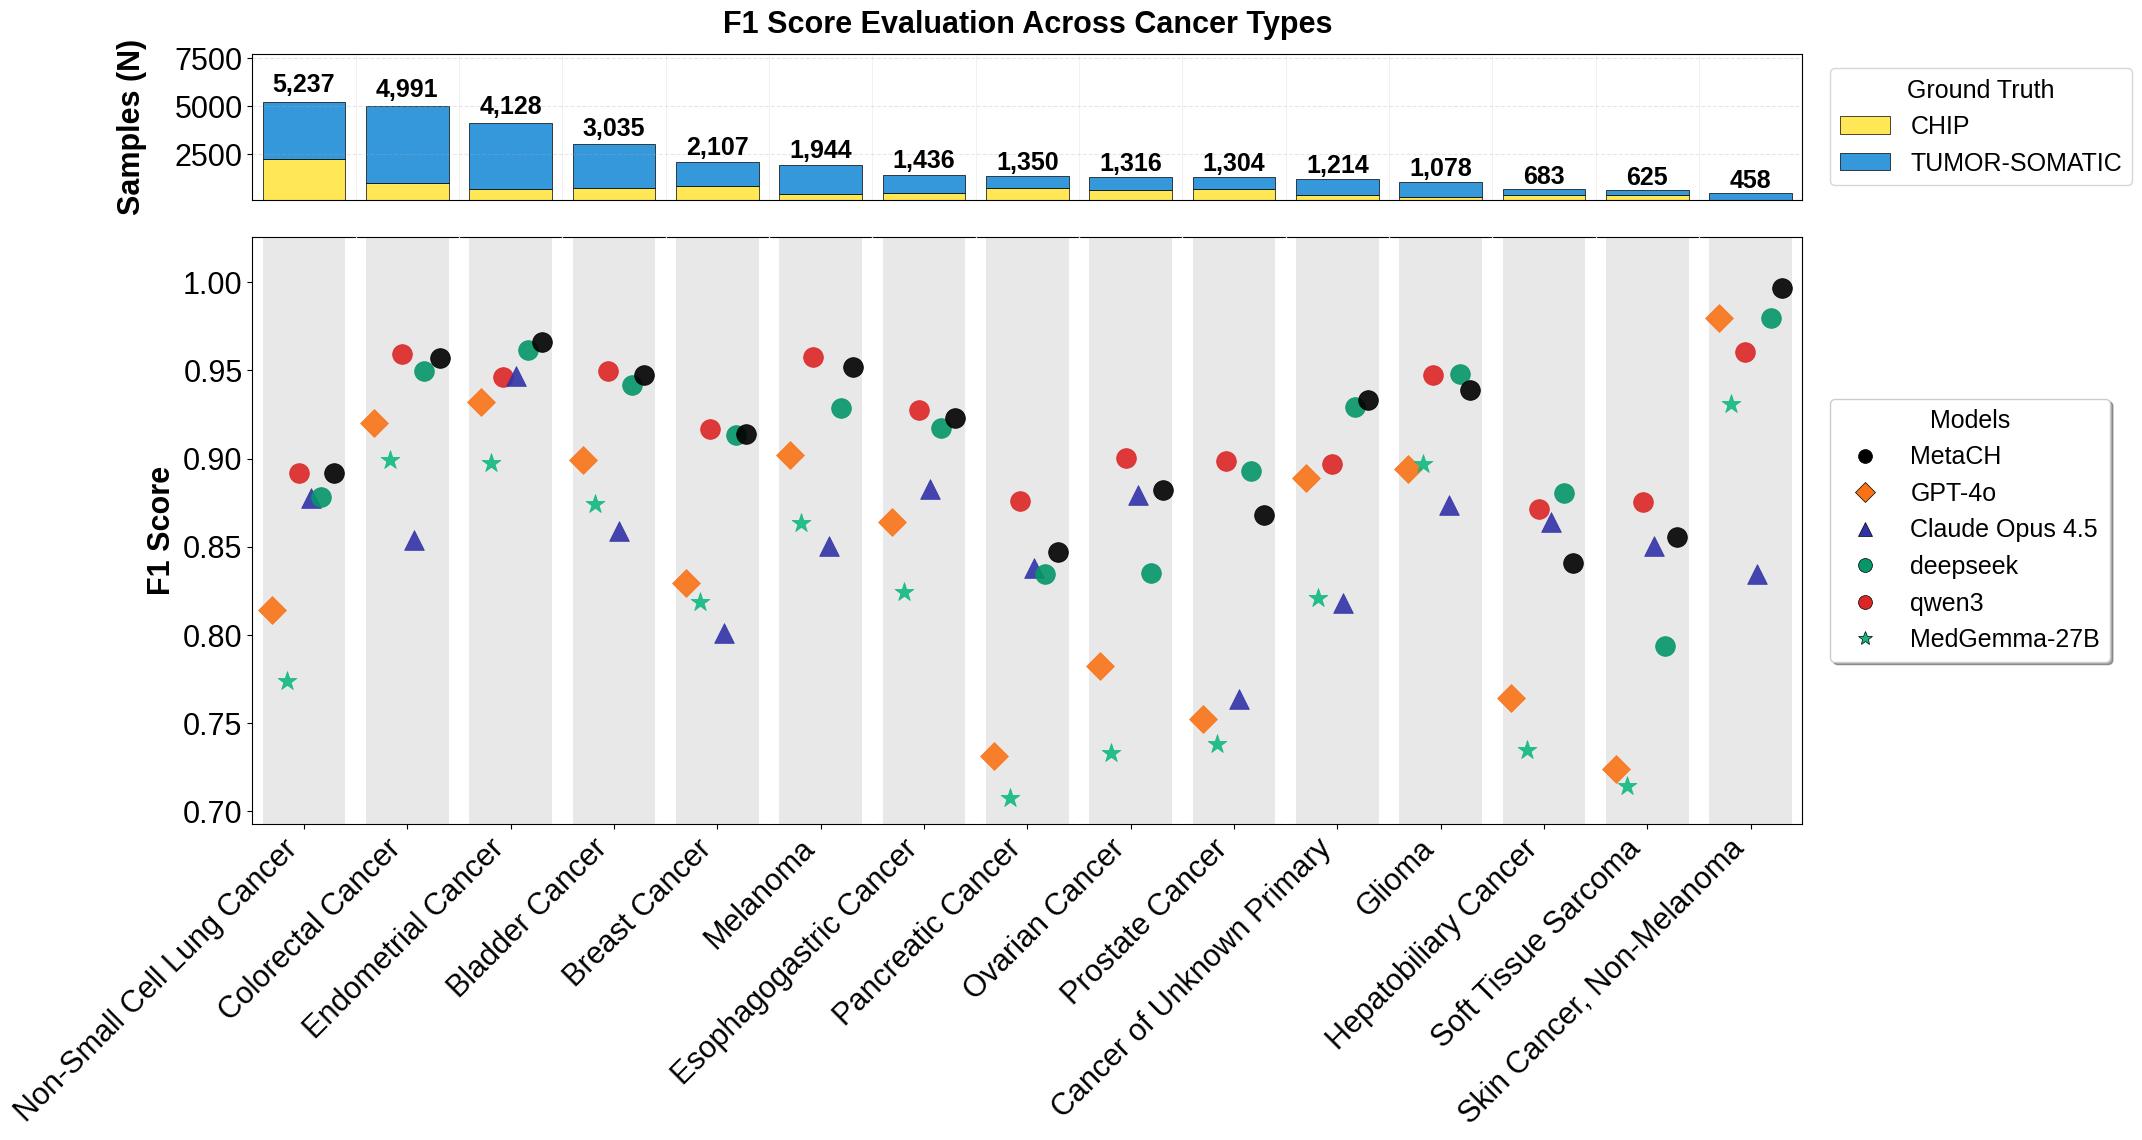

In [15]:
# Save merged dataframe
output_file = 'merged_predictions_all_models_ALL_with_chr.csv'
df.to_csv(output_file, index=False)
print(f"\nSaved merged predictions to {output_file}")
print(f"Shape: {df.shape}")

# Calculate metrics
metric_name = "f1"
print(f"\nCalculating {metric_name }metrics by cancer type...")
metrics_df = calculate_metrics_by_cancer_type(df, MODEL_NAMES, metric=metric_name)

# Save metrics
metrics_file = f'{metric_name}_metrics_by_cancer_type.csv'
metrics_df.to_csv(metrics_file, index=False)
print(f"Saved metrics to {metrics_file}")

# Create visualization with custom parameters
print("\nCreating visualization...")
fig = create_accuracy_plot(
    metrics_df, 
    df,  # Pass the full dataframe for overall accuracy calculation
    top_n=15,
    jitter_amount=0.6,  # Increased jittering (0-1 scale)
    y_min=80,  # Start y-axis at 80%
    models_to_include=["MetaCH", "gpt-4o", "claude-opus-45", "deepseek", "qwen3", "medgemma"],
    legend_position='right',
    metric=metric_name,
    fontsize=22
)
fig.savefig("/data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/1_mutation_status_prediction/plots/supp-fig2-mutation_status_f1_across_cancer.pdf", bbox_inches='tight')



Calculating accuracymetrics by cancer type...
Saved metrics to accuracy_metrics_by_cancer_type.csv

Creating visualization...
called calculate_overall_accuracy


/tmp/ipykernel_1602928/3671952479.py:626: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


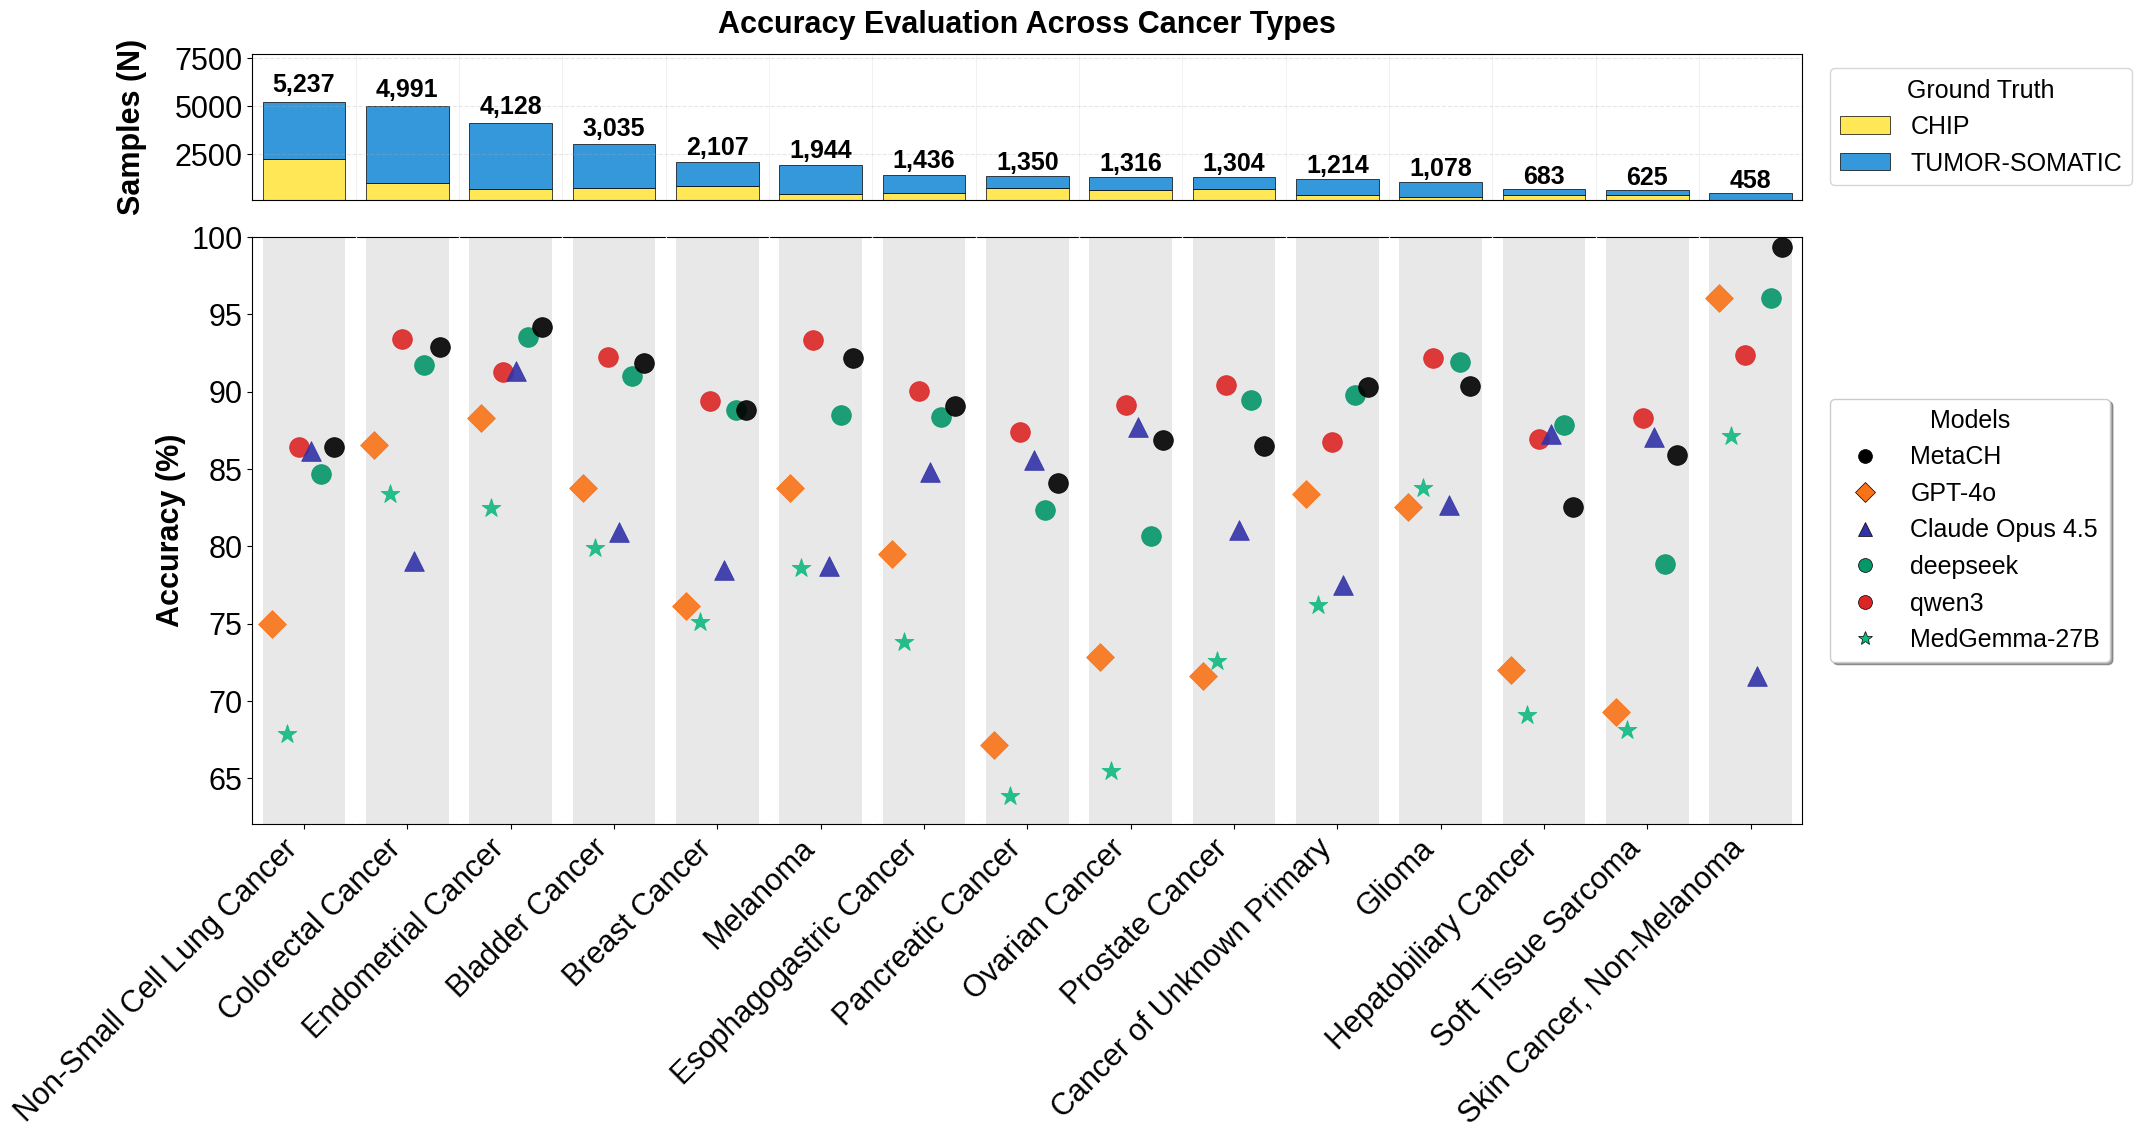

In [16]:
# Calculate metrics
metric_name = "accuracy"
print(f"\nCalculating {metric_name }metrics by cancer type...")
metrics_df = calculate_metrics_by_cancer_type(df, MODEL_NAMES, metric=metric_name)

# Save metrics
metrics_file = f'{metric_name}_metrics_by_cancer_type.csv'
metrics_df.to_csv(metrics_file, index=False)
print(f"Saved metrics to {metrics_file}")

# Create visualization with custom parameters
print("\nCreating visualization...")
fig = create_accuracy_plot(
    metrics_df, 
    df,  # Pass the full dataframe for overall accuracy calculation
    top_n=15,
    jitter_amount=0.6,  # Increased jittering (0-1 scale)
    y_min=80,  # Start y-axis at 80%
    models_to_include=["MetaCH", "gpt-4o", "claude-opus-45", "deepseek", "qwen3", "medgemma"],
    legend_position='right',
    metric=metric_name,
    fontsize=22
)
fig.savefig("/data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/1_mutation_status_prediction/plots/supp-fig2-mutation_status_accuracy_across_cancer.pdf", bbox_inches='tight')


{'MetaCH': 89.67310765654511, 'gpt-4o': 79.6803719308441, 'claude-opus-45': 83.57402295510678, 'deepseek': 88.2667441522592, 'qwen3': 89.93171582158942, 'medgemma': 75.49614993462153}


/tmp/ipykernel_1602928/3671952479.py:1075: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


{'MetaCH': 92.6812191103789, 'gpt-4o': 86.32176039119804, 'claude-opus-45': 86.84277900616782, 'deepseek-r1': 85.57290738871404, 'qwen3-vl-235b-a22b': 90.84582985736668, 'medgemma': 83.33827277576907}


/tmp/ipykernel_1602928/3671952479.py:1075: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


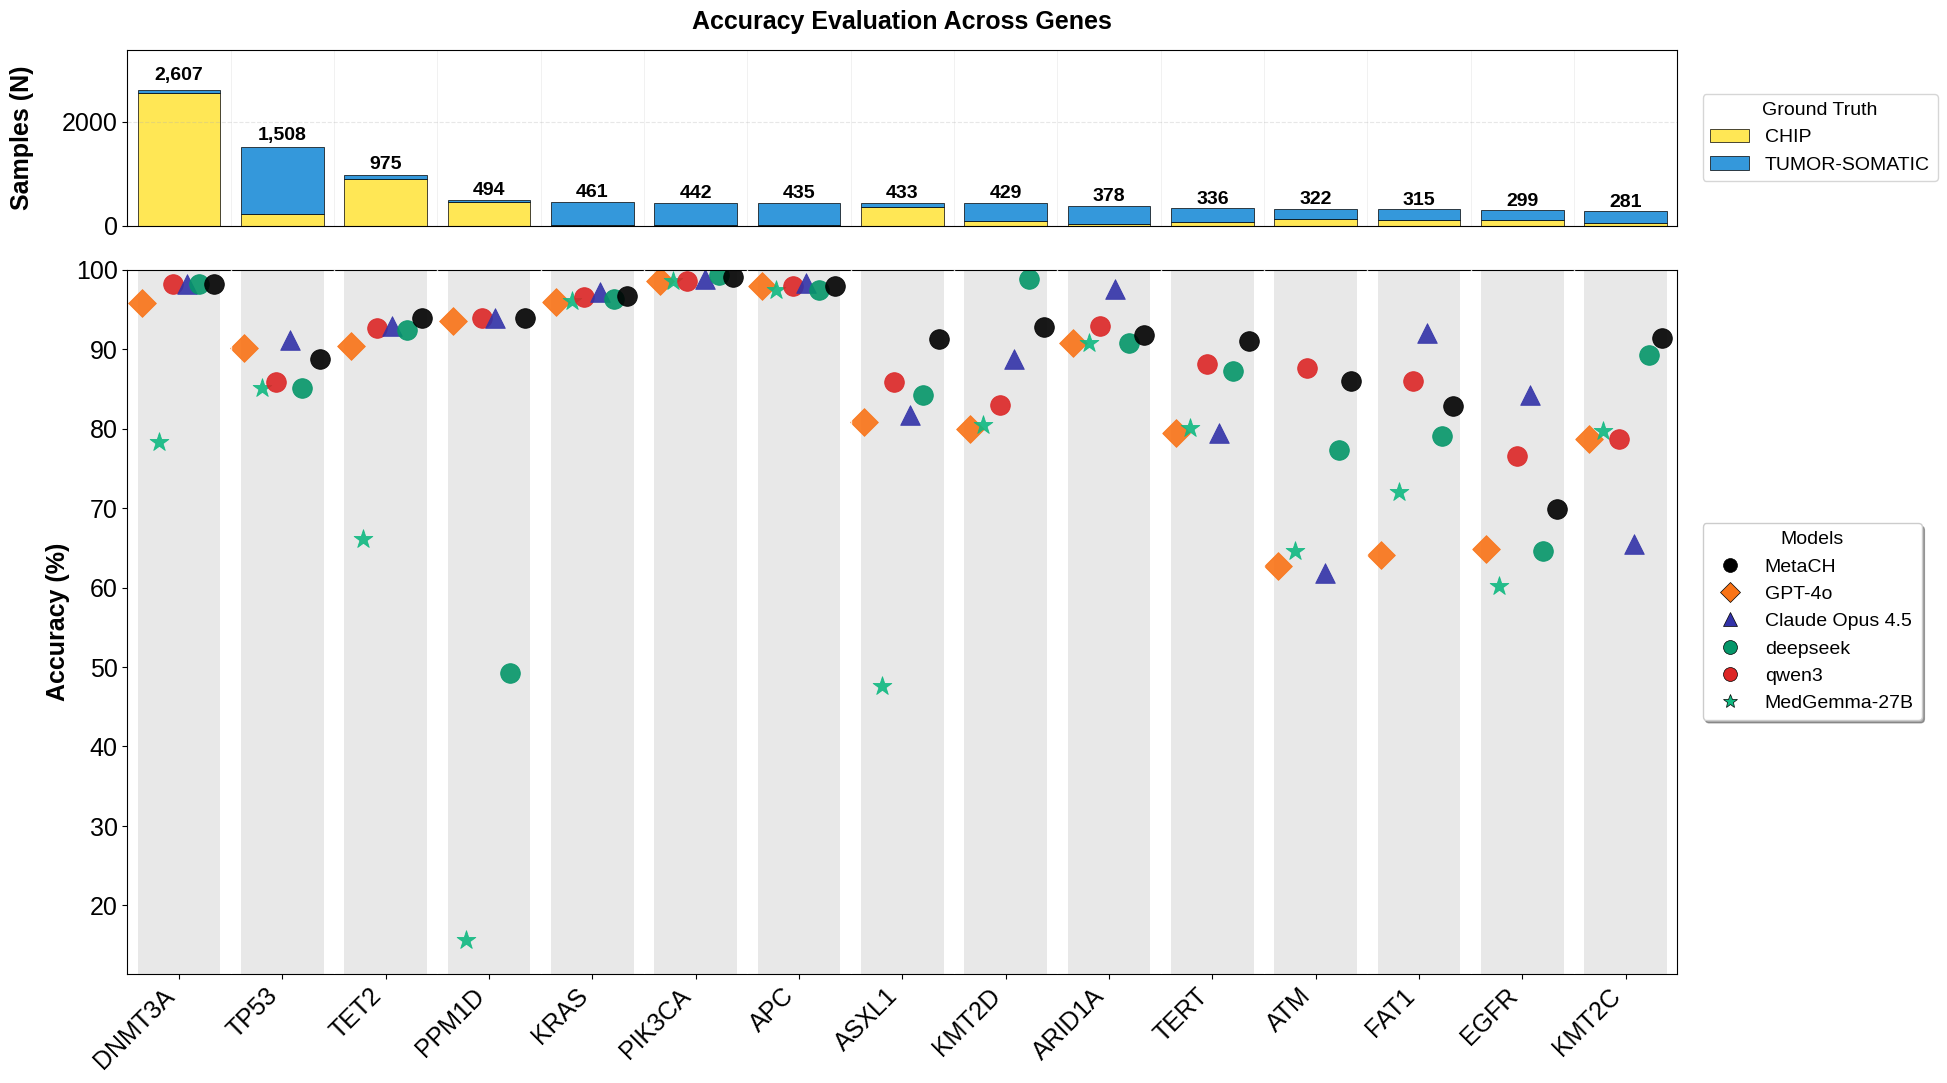

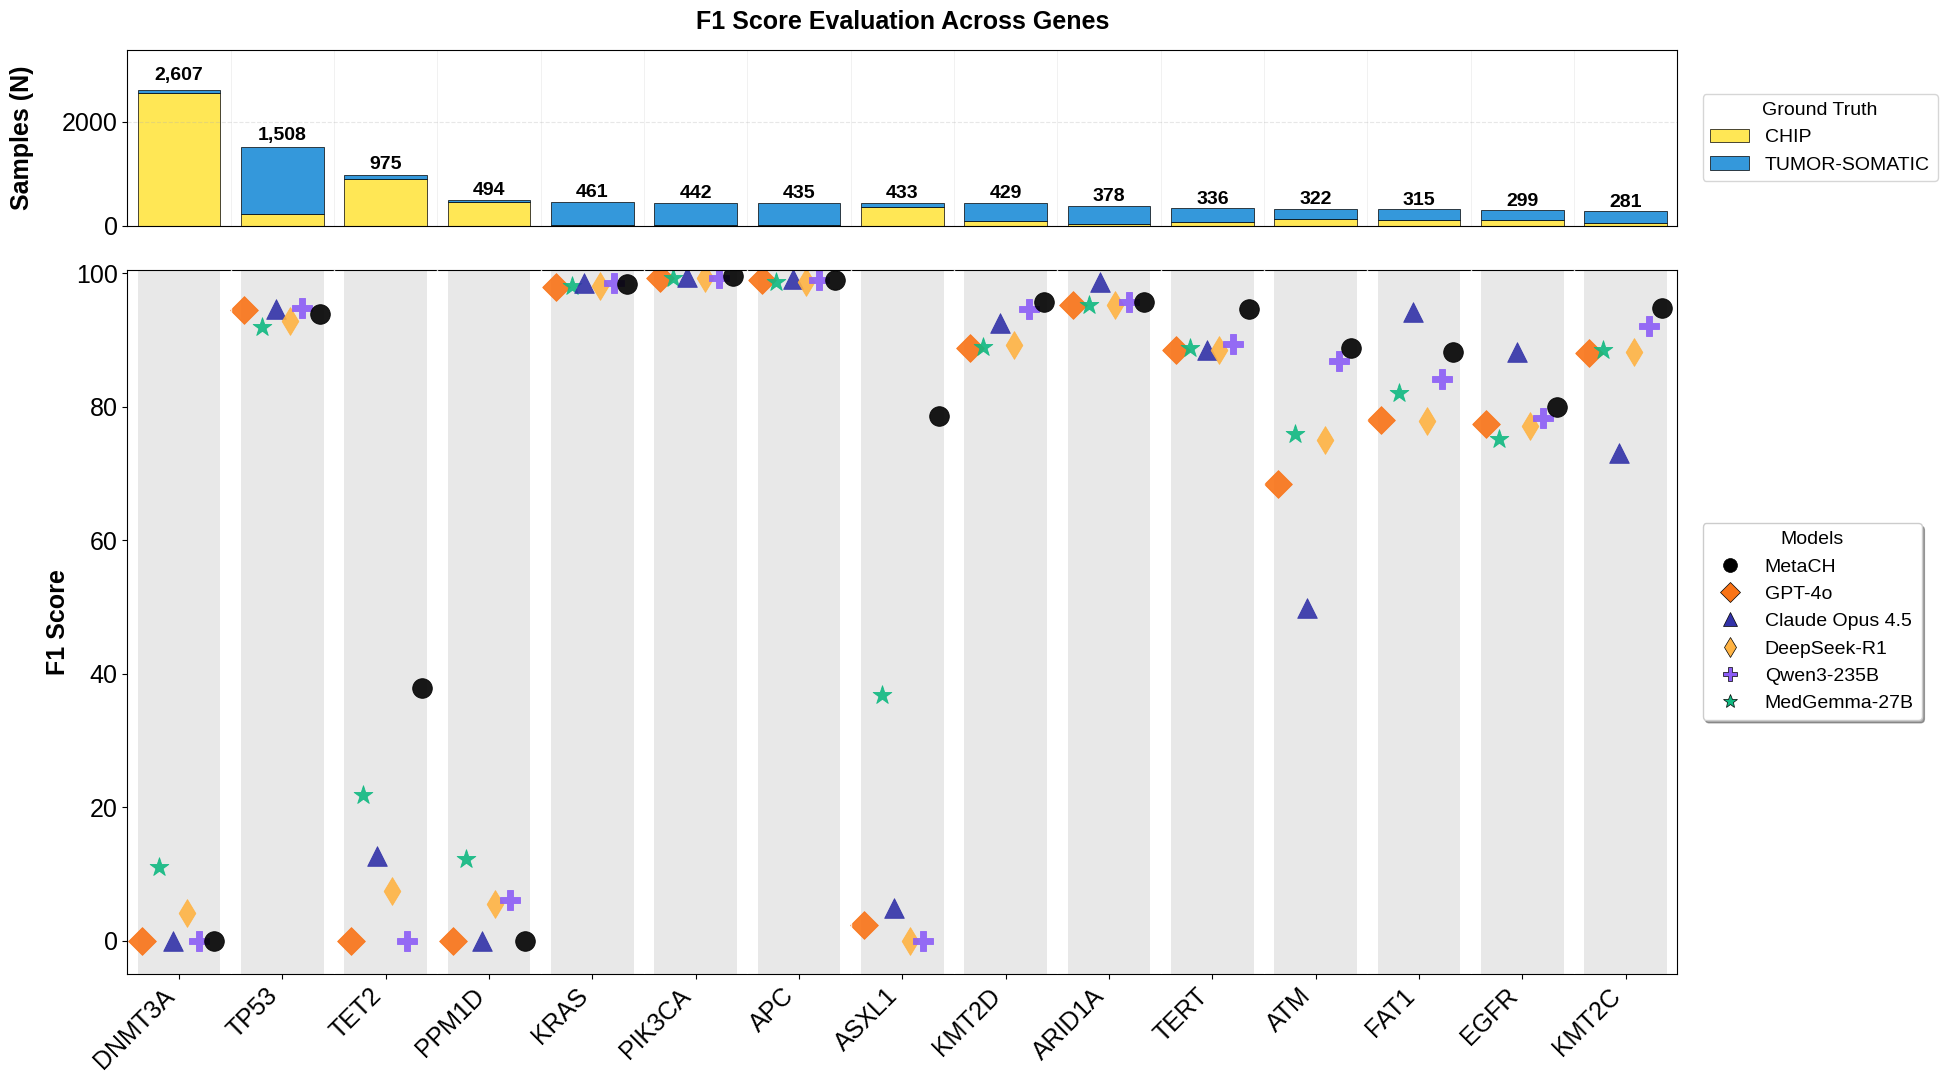

In [17]:
# Calculate metrics by gene
gene_metrics_df = calculate_metrics_by_gene(
    df, 
    MODEL_NAMES, 
    gene_col='Hugo_Symbol',  # or 'Hugo_Symbol'
    metric='accuracy', 
    min_samples=10
)

# Create visualization
fig = create_gene_performance_plot(
    gene_metrics_df,
    df,
    gene_col='Hugo_Symbol',  # or 'Hugo_Symbol'
    top_n=15,
    models_to_include=["MetaCH", "gpt-4o", "claude-opus-45", "deepseek", "qwen3", "medgemma"],
    metric='accuracy',
    legend_position='right',
    fontsize=18,
    figsize=(20, 12),
    jitter_amount=0.7
)
fig.savefig("/data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/1_mutation_status_prediction/plots/supp-fig2-mutation_status_accuracy_across_gene.pdf", bbox_inches='tight')

# Calculate metrics by gene
gene_metrics_df = calculate_metrics_by_gene(
    df, 
    MODEL_NAMES, 
    gene_col='Hugo_Symbol',  # or 'Hugo_Symbol'
    metric='f1', 
    min_samples=10
)

# Create visualization
fig = create_gene_performance_plot(
    gene_metrics_df,
    df,
    gene_col='Hugo_Symbol',  # or 'Hugo_Symbol'
    top_n=15,
    models_to_include=["MetaCH", "gpt-4o", "claude-opus-45", "deepseek-r1", "qwen3-vl-235b-a22b", "medgemma"],
    metric='f1',
    legend_position='right',
    fontsize=18,
    figsize=(20, 12),
    jitter_amount=0.7
)
fig.savefig("/data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/1_mutation_status_prediction/plots/supp-fig2-mutation_status_f1_across_gene.pdf", bbox_inches='tight')


In [18]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import os

# Assuming df is already loaded from your load_all_model_predictions function

def calculate_metrics_per_model(df, model_names, ground_truth_col='ground_truth'):
    """
    Calculate accuracy, precision, recall, and F1 score for each model
    
    Args:
        df: DataFrame with predictions and ground truth
        model_names: List of model names
        ground_truth_col: Name of the ground truth column
    
    Returns:
        DataFrame with metrics for each model
    """
    metrics_list = []
    
    for model_name in model_names:
        print("model_name: ", model_name)
        pred_col = f'{model_name}_pred'
        
        # Check if prediction column exists
        if pred_col not in df.columns:
            print(f"Warning: {pred_col} not found in dataframe")
            continue
        
        # Filter out rows with missing predictions or ground truth
        valid_mask = df[pred_col].notna() & df[ground_truth_col].notna()
        df_valid = df[valid_mask].copy()
        
        if len(df_valid) == 0:
            print(f"Warning: No valid predictions for {model_name}")
            continue
        
        y_true = df_valid[ground_truth_col]
        y_pred = df_valid[pred_col]
        y_true = y_true.map(_normalize_label)
        y_pred = y_pred.map(_normalize_label)
        
        # Calculate metrics
        # For binary classification (Oncogenic vs not)
        try:
            accuracy = accuracy_score(y_true, y_pred)
            
            # Check if binary or multiclass
            unique_labels = sorted(set(y_true.dropna()) | set(y_pred.dropna()))
            
            if len(unique_labels) == 2:
                # Binary classification
                precision = precision_score(y_true, y_pred, pos_label=unique_labels[1], zero_division=0)
                recall = recall_score(y_true, y_pred, pos_label=unique_labels[1], zero_division=0)
                f1 = f1_score(y_true, y_pred, pos_label=unique_labels[1], zero_division=0)
            else:
                # Multiclass - use weighted average
                precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
                recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
                f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
            
            metrics_list.append({
                'model': model_name,
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1_score': f1,
                'n_samples': len(df_valid),
                'n_classes': len(unique_labels)
            })
            
            print(f"\n{model_name}:")
            print(f"  Samples: {len(df_valid)}")
            print(f"  Accuracy: {accuracy:.4f}")
            print(f"  Precision: {precision:.4f}")
            print(f"  Recall: {recall:.4f}")
            print(f"  F1 Score: {f1:.4f}")
            
        except Exception as e:
            print(f"Error calculating metrics for {model_name}: {e}")
            continue
    
    # Create metrics dataframe
    metrics_df = pd.DataFrame(metrics_list)
    
    return metrics_df


def calculate_detailed_metrics_per_model(df, model_names, ground_truth_col='OncoKB_label'):
    """
    Calculate detailed metrics including per-class metrics
    
    Args:
        df: DataFrame with predictions and ground truth
        model_names: List of model names
        ground_truth_col: Name of the ground truth column
    
    Returns:
        Dictionary with detailed metrics for each model
    """
    detailed_metrics = {}
    
    for model_name in model_names:
        pred_col = f'{model_name}_pred'
        
        if pred_col not in df.columns:
            continue
        
        # Filter valid predictions
        valid_mask = df[pred_col].notna() & df[ground_truth_col].notna()
        df_valid = df[valid_mask].copy()
        
        if len(df_valid) == 0:
            continue
        
        y_true = df_valid[ground_truth_col]
        y_pred = df_valid[pred_col]
        y_true = y_true.map(_normalize_label)
        y_pred = y_pred.map(_normalize_label)
        
        # Generate classification report
        report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
        
        detailed_metrics[model_name] = {
            'classification_report': report,
            'n_samples': len(df_valid)
        }
        
        print(f"\n{'='*60}")
        print(f"Detailed Metrics for {model_name}")
        print(f"{'='*60}")
        print(classification_report(y_true, y_pred, zero_division=0))
    
    return detailed_metrics


# Calculate metrics
print("\n" + "="*60)
print("CALCULATING METRICS FOR ALL MODELS")
print("="*60)
for name in MODEL_NAMES:
    df = df[df[f'{name}_pred']!='Error']
metrics_df = calculate_metrics_per_model(df, MODEL_NAMES, ground_truth_col='ground_truth')

# Save metrics to CSV
os.makedirs(OUT_METRICS_DIR, exist_ok=True)
metrics_output_path = os.path.join(OUT_METRICS_DIR, "model_performance_metrics.csv")
metrics_df.to_csv(metrics_output_path, index=False)
print(f"\nMetrics saved to: {metrics_output_path}")

# Calculate detailed metrics
detailed_metrics = calculate_detailed_metrics_per_model(df, MODEL_NAMES, ground_truth_col='ground_truth')

# Save detailed metrics summary
detailed_summary = []
for model_name, metrics in detailed_metrics.items():
    report = metrics['classification_report']
    detailed_summary.append({
        'model': model_name,
        'accuracy': report['accuracy'],
        'macro_avg_precision': report['macro avg']['precision'],
        'macro_avg_recall': report['macro avg']['recall'],
        'macro_avg_f1': report['macro avg']['f1-score'],
        'weighted_avg_precision': report['weighted avg']['precision'],
        'weighted_avg_recall': report['weighted avg']['recall'],
        'weighted_avg_f1': report['weighted avg']['f1-score'],
        'n_samples': metrics['n_samples']
    })

detailed_summary_df = pd.DataFrame(detailed_summary)
detailed_output_path = os.path.join(OUT_METRICS_DIR, "model_performance_detailed.csv")
detailed_summary_df.to_csv(detailed_output_path, index=False)
print(f"Detailed metrics saved to: {detailed_output_path}")

# Display summary
print("\n" + "="*60)
print("SUMMARY OF ALL MODELS")
print("="*60)
print(metrics_df.to_string(index=False))


CALCULATING METRICS FOR ALL MODELS
model_name:  gpt-5

gpt-5:
  Samples: 34415
  Accuracy: 0.7981
  Precision: 0.7817
  Recall: 0.9666
  F1 Score: 0.8644
model_name:  o3-mini

o3-mini:
  Samples: 34415
  Accuracy: 0.8003
  Precision: 0.7751
  Recall: 0.9859
  F1 Score: 0.8679
model_name:  gpt-4o

gpt-4o:
  Samples: 34415
  Accuracy: 0.7968
  Precision: 0.7818
  Recall: 0.9636
  F1 Score: 0.8632
model_name:  medgemma

medgemma:
  Samples: 34415
  Accuracy: 0.7550
  Precision: 0.7610
  Recall: 0.9210
  F1 Score: 0.8334
model_name:  qwen3

qwen3:
  Samples: 34415
  Accuracy: 0.8993
  Precision: 0.9022
  Recall: 0.9519
  F1 Score: 0.9264
model_name:  claude-sonnet-37

claude-sonnet-37:
  Samples: 34415
  Accuracy: 0.7867
  Precision: 0.9791
  Recall: 0.6943
  F1 Score: 0.8125
model_name:  claude-sonnet-45

claude-sonnet-45:
  Samples: 34415
  Accuracy: 0.8115
  Precision: 0.8385
  Recall: 0.8877
  F1 Score: 0.8624
model_name:  claude-opus-45

claude-opus-45:
  Samples: 34415
  Accuracy: 0

In [19]:
df

,SAMPLE_ID,PATIENT_ID_x,CANCER_TYPE,ground_truth,Hugo_Symbol,Variant_Classification,Variant_Type,Reference_Allele,Tumor_Seq_Allele2,Chromosome,...,claude-opus-45_prob,deepseek_pred,deepseek_prob,deepseek-r1_pred,deepseek-r1_prob,qwen3-vl-235b-a22b_pred,qwen3-vl-235b-a22b_prob,MetaCH_pred,MetaCH_prob,PATIENT_ID
0,GENIE-MSK-P-0045737-T01-IM6,GENIE-MSK-P-0045737,Non-Small Cell Lung Cancer,TUMOR-SOMATIC,EGFR,Missense_Mutation,SNP,T,G,7,...,0.95,TUMOR-SOMATIC,0.85,TUMOR-SOMATIC,0.92,TUMOR-SOMATIC,0.92,TUMOR-SOMATIC,0.013227,P-0045737
1,GENIE-MSK-P-0026942-T02-IM6,GENIE-MSK-P-0026942,Non-Small Cell Lung Cancer,TUMOR-SOMATIC,EGFR,In_Frame_Del,DEL,ATTAAGAGAAGCAAC,-,7,...,0.97,TUMOR-SOMATIC,0.95,TUMOR-SOMATIC,0.89,TUMOR-SOMATIC,0.92,TUMOR-SOMATIC,0.014332,P-0026942
2,P-0047608-N01-IM6,P-0047608,Endometrial Cancer,CHIP,JAK2,Missense_Mutation,SNP,G,T,9,...,0.92,CHIP,0.87,CHIP,0.85,CHIP,0.85,CHIP,0.509037,P-0047608
3,GENIE-MSK-P-0033315-T03-IM6,GENIE-MSK-P-0033315,Non-Small Cell Lung Cancer,TUMOR-SOMATIC,EGFR,In_Frame_Del,DEL,TAAGAGAAGCAACATCTC,-,7,...,0.97,TUMOR-SOMATIC,0.95,TUMOR-SOMATIC,0.95,TUMOR-SOMATIC,0.92,TUMOR-SOMATIC,0.015990,P-0033315
4,GENIE-MSK-P-0026942-T06-IM7,GENIE-MSK-P-0026942,Non-Small Cell Lung Cancer,TUMOR-SOMATIC,EGFR,In_Frame_Del,DEL,ATTAAGAGAAGCAAC,-,7,...,0.97,TUMOR-SOMATIC,0.95,TUMOR-SOMATIC,0.95,TUMOR-SOMATIC,0.95,TUMOR-SOMATIC,0.014332,P-0026942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34410,P-0058524-N01-IM6,P-0058524,Endometrial Cancer,CHIP,IRF4,Missense_Mutation,SNP,C,T,6,...,0.62,CHIP,0.87,CHIP,0.72,CHIP,0.92,CHIP,0.612750,P-0058524
34411,P-0035156-N01-IM6,P-0035156,Non-Small Cell Lung Cancer,CHIP,EZH2,Missense_Mutation,SNP,G,A,7,...,0.72,CHIP,0.87,CHIP,0.68,CHIP,0.82,TUMOR-SOMATIC,0.053628,P-0035156
34412,P-0032362-N01-IM6,P-0032362,Glioma,CHIP,DNMT3B,Missense_Mutation,SNP,G,A,20,...,0.62,CHIP,0.87,TUMOR-SOMATIC,0.65,CHIP,0.65,CHIP,0.583696,P-0032362
34413,P-0034628-N01-IM6,P-0034628,Pancreatic Cancer,CHIP,TET1,Silent,SNP,G,A,10,...,0.62,CHIP,0.87,CHIP,0.68,CHIP,0.92,CHIP,0.778851,P-0034628


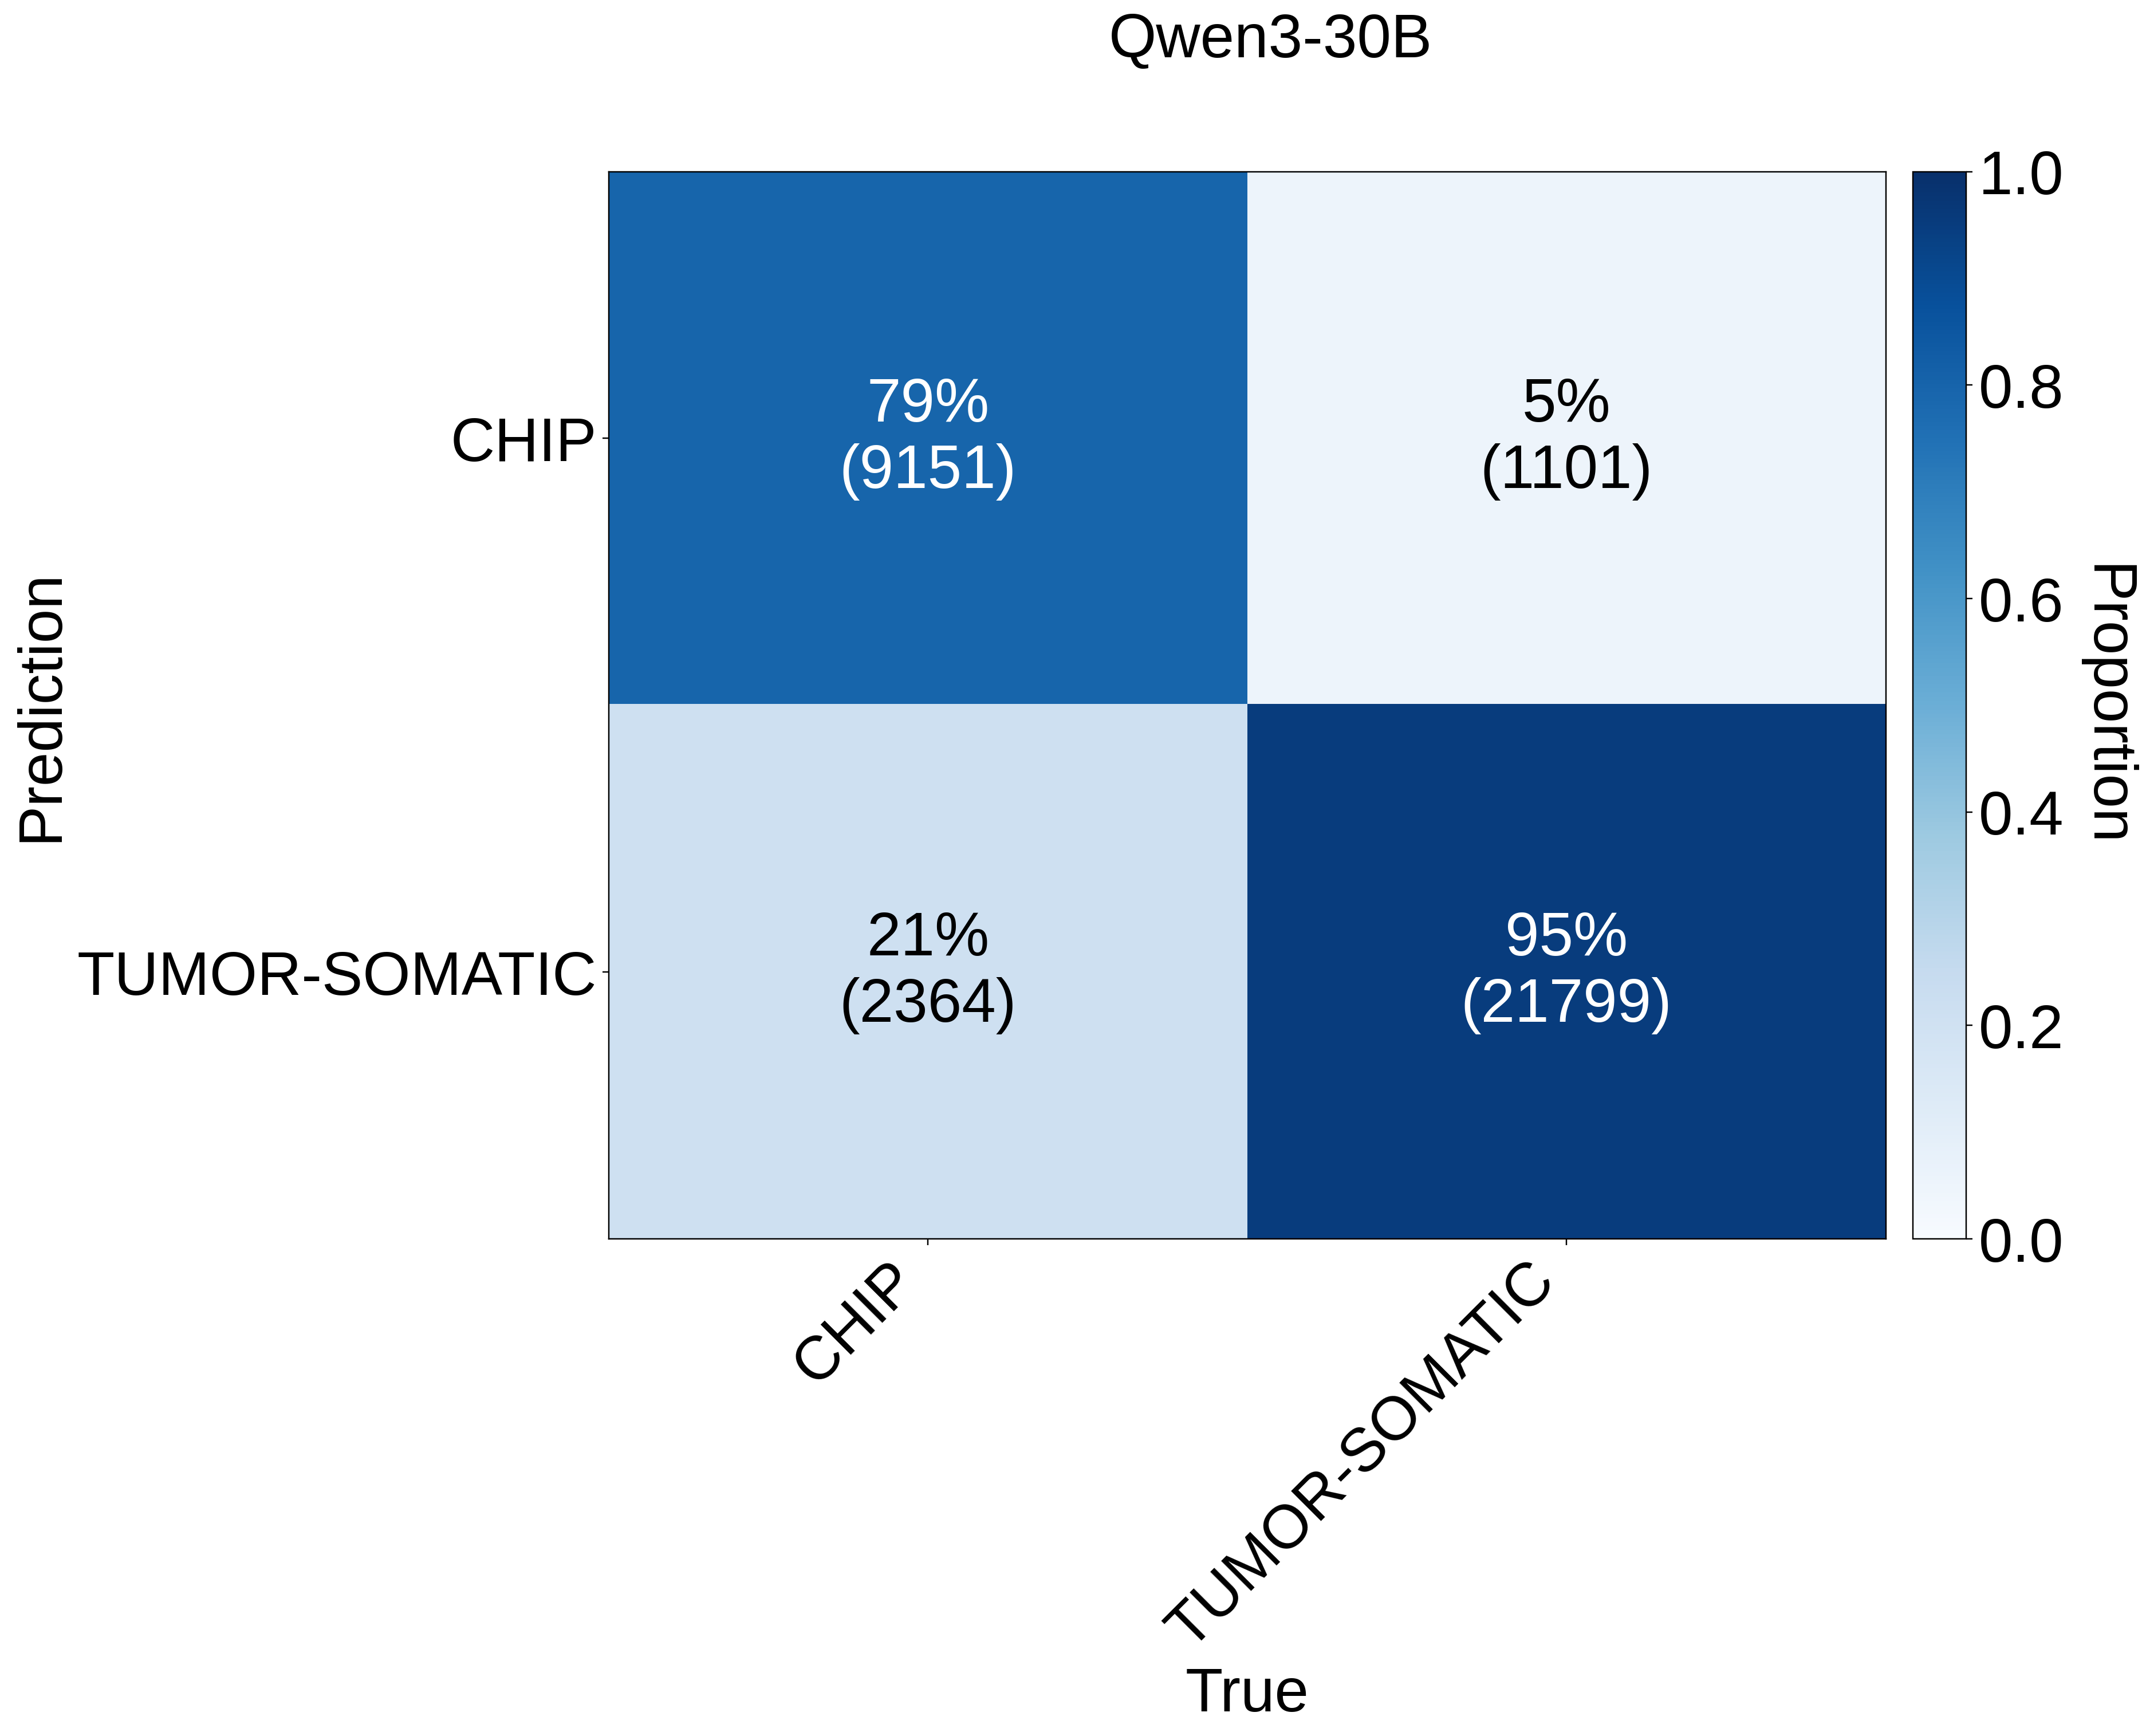

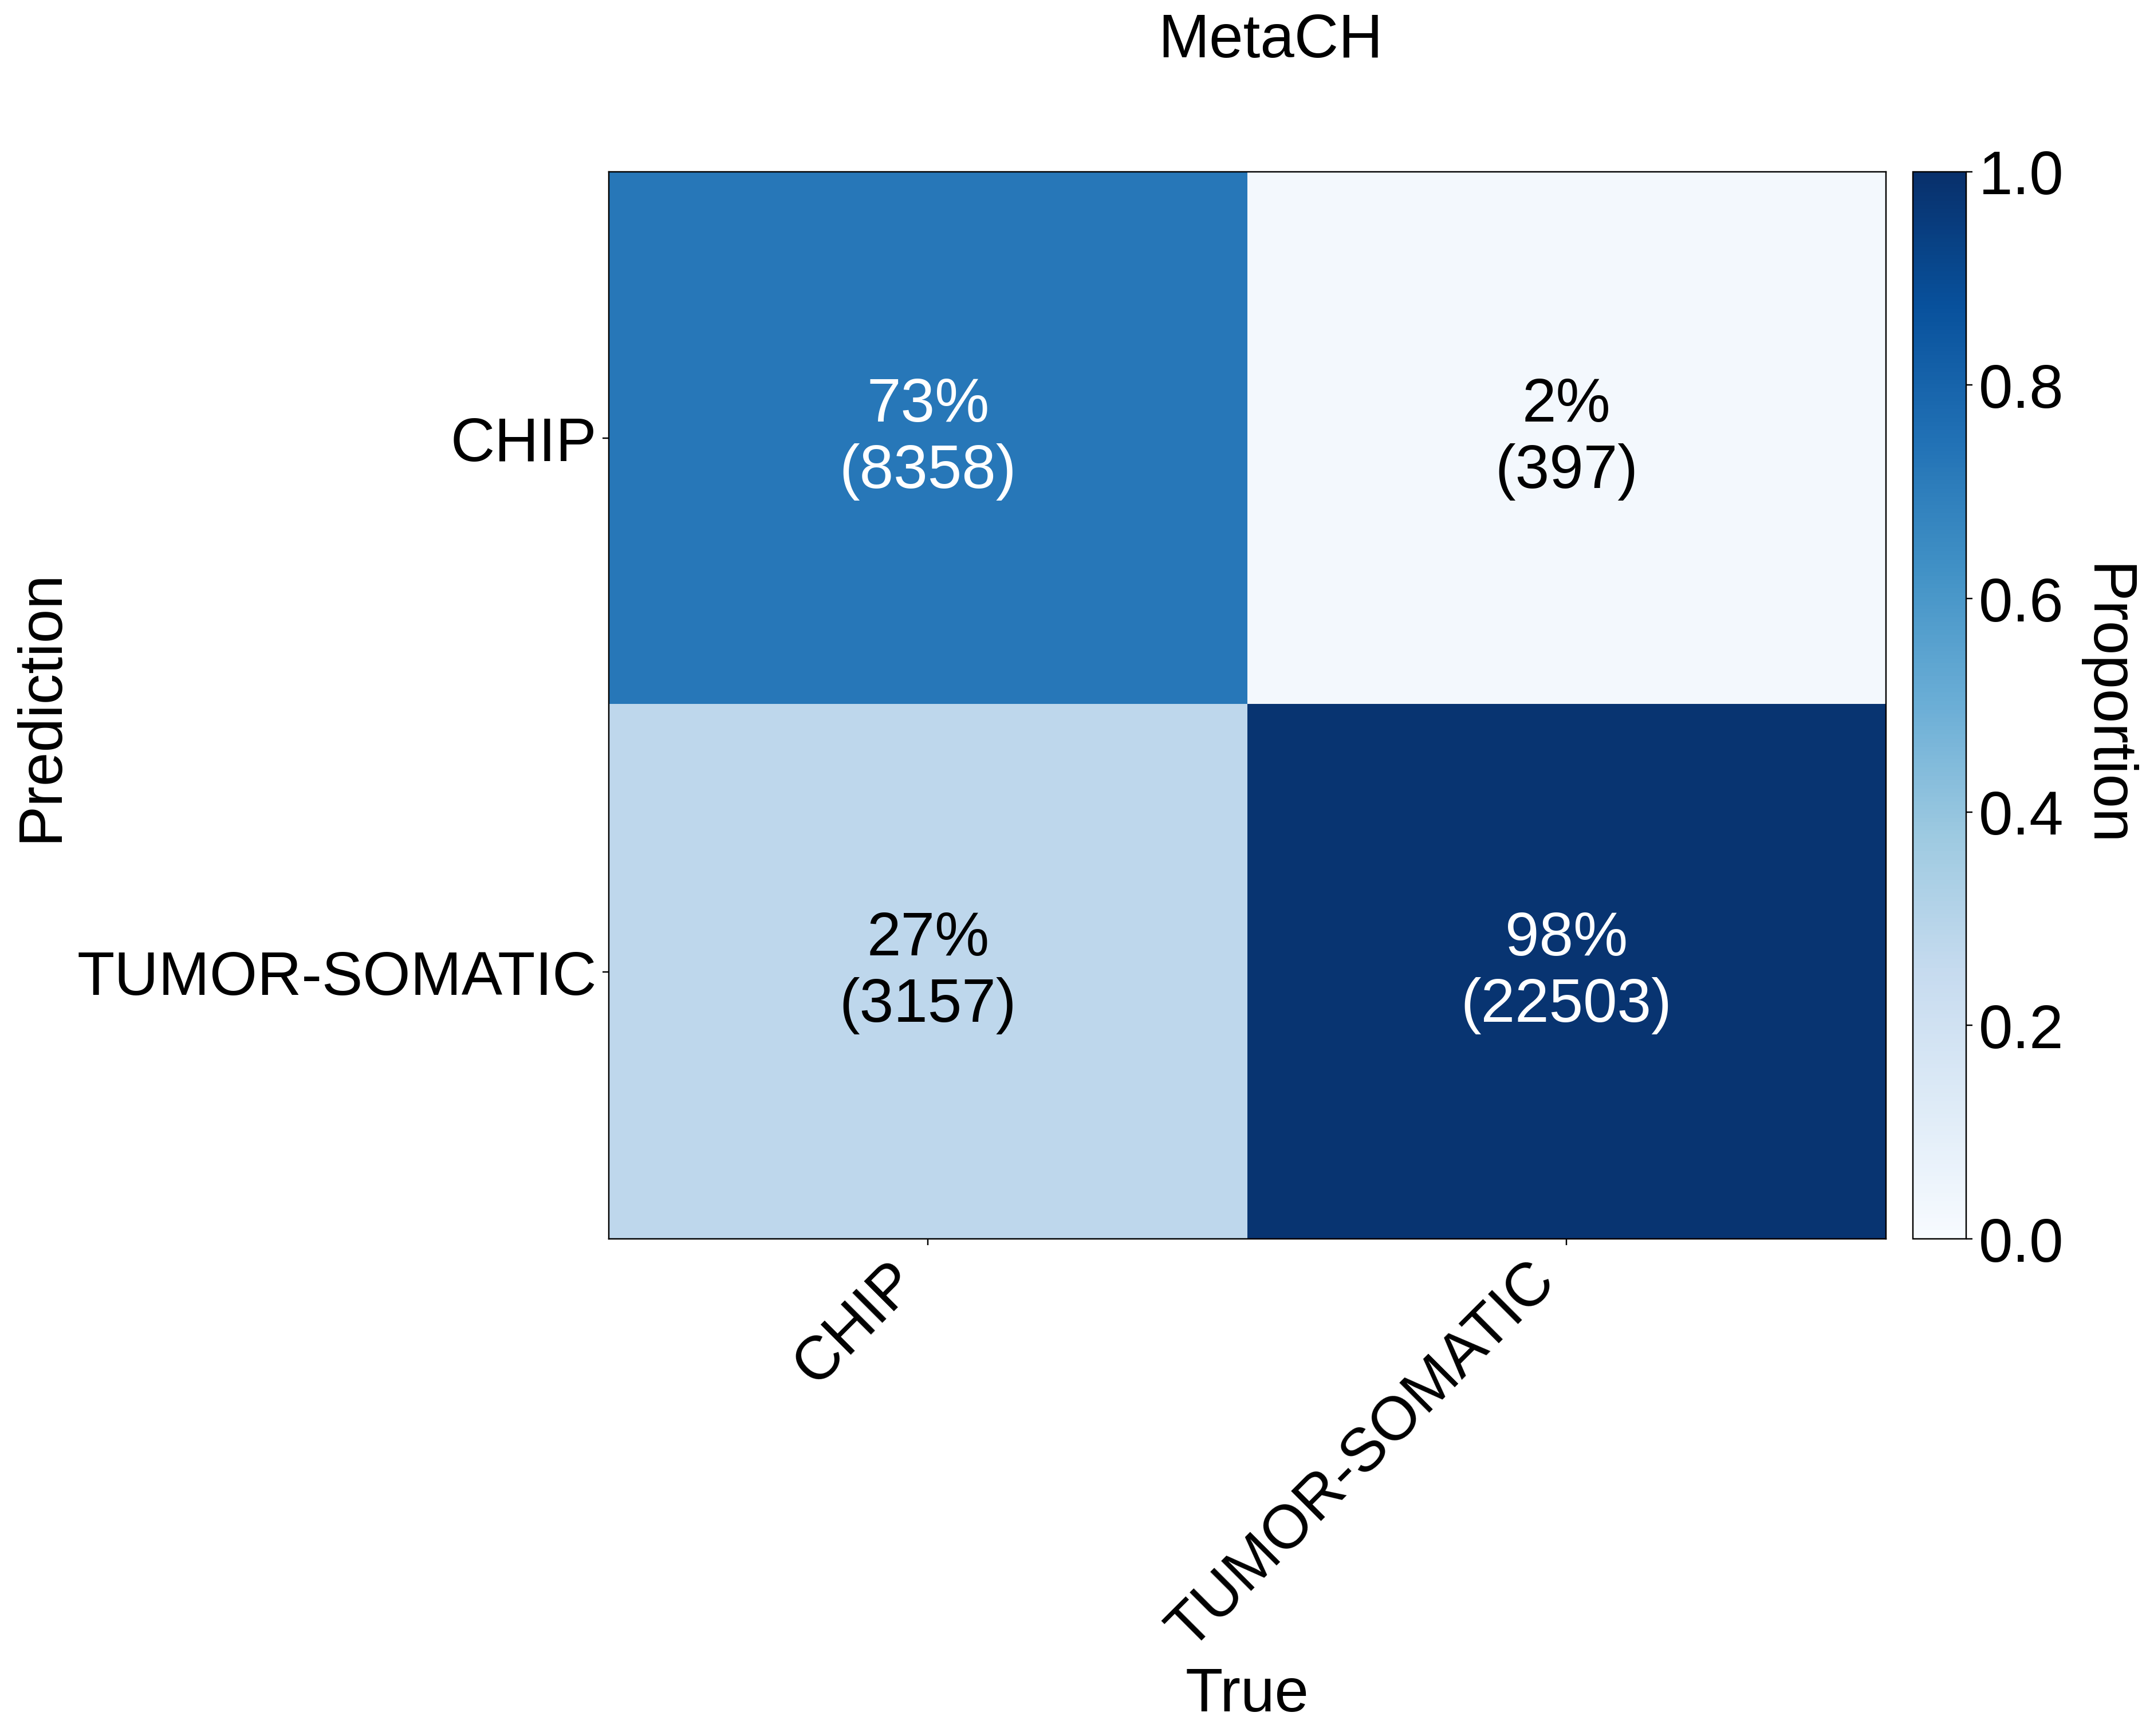

In [21]:
import numpy as np
import pandas as pd
import unicodedata
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, Normalize
from sklearn.metrics import confusion_matrix

# --- keep your helper stacks here if you use recall/precision bars ---
# (omitted for brevity—no changes needed to those helpers)

def plot_confusion_with_pr(
    df,
    true_col="ground_truth",
    pred_col="gpt-5_pred",
    prob_col=None,
    normalize="true",               # 'true' | 'pred' | 'all' | None
    threshold=0.5,
    label_order=None,
    normalize_labels=True,
    sort_by_diagonal=True,
    show_recall=False,
    show_precision=False,
    show_colorbar=True,
    diverging=False,                # keep False to use single-hue
    cmap="Blues",                   # default blue
    cbar_limits=(0, 1),            # fixed 0..1 when normalized
    annot_decimals=0,
    auto_contrast_annots=True,
    annot_dark="white",
    annot_light="black",
    contrast_threshold=0.5,
    figsize=(14, 11),
    fonts=None,
    title="Confusion Matrix",
    # NEW: if True, append any labels present in data but missing from label_order to the END
    append_unseen_to_end=True,
    fig_path=None
):
    fonts = fonts or {'title':18,'axis':12,'tick':11,'annot':18,'legend':9}

    _LABEL_CANON = {
        'tumor': 'TUMOR-SOMATIC',
        'blood': 'CHIP',
    }
    def _norm_name(s):
        if not isinstance(s, str): return s
        s = unicodedata.normalize("NFKD", s)
        s = (s.replace('\u2010','-').replace('\u2013','-').replace('\u2014','-')
               .replace(',', '').strip())
        return _LABEL_CANON.get(s.lower(), s)

    data = df.copy()
    if normalize_labels:
        data[true_col] = data[true_col].map(_norm_name)
        data[pred_col] = data[pred_col].map(_norm_name)

    # --- BUILD A STABLE LABEL LIST -------------------------------------------------
    observed = pd.Index(data[true_col]).union(data[pred_col]).dropna().unique().tolist()
    if label_order is None:
        # deterministic default when no order is provided
        labels = sorted(observed)
        fixed_order = False
    else:
        # enforce the given order strictly, deduping while preserving order
        base = [*dict.fromkeys(label_order)]
        if normalize_labels:
            base = [_norm_name(x) for x in base]
        if append_unseen_to_end:
            extras = [x for x in observed if x not in base]
            labels = base + extras
        else:
            labels = base
        fixed_order = True  # we must NOT override this later
    # -----------------------------------------------------------------------------

    cm_counts = confusion_matrix(data[true_col], data[pred_col], labels=labels).T
    cm_norm = None if normalize is None else confusion_matrix(
        data[true_col], data[pred_col], labels=labels, normalize=normalize
    ).T

    # Only allow diagonal-based resorting if the order wasn't fixed by the user
    if sort_by_diagonal and not fixed_order:
        diag_src = (cm_norm if cm_norm is not None else cm_counts.astype(float))
        order = np.argsort(np.diag(diag_src))[::-1]
        labels = [labels[i] for i in order]
        cm_counts = cm_counts[order][:, order]
        if cm_norm is not None:
            cm_norm = cm_norm[order][:, order]

    matrix = cm_norm if cm_norm is not None else cm_counts.astype(float)

    # color normalization
    if cm_norm is not None:
        norm = (TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1) if diverging
                else Normalize(vmin=cbar_limits[0], vmax=cbar_limits[1]))
    else:
        norm = None  # raw counts

    # layout
    fig, ax = plt.subplots(figsize=figsize, dpi=220)

    # heatmap
    im = ax.imshow(matrix, cmap=cmap, norm=norm, aspect='auto')
    ax.set_xlabel("True", fontsize=fonts['axis'])
    ax.set_ylabel("Prediction", fontsize=fonts['axis'])
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=fonts['tick'])
    ax.set_yticklabels(labels, fontsize=fonts['tick'])

    def _rel_lum(rgb):
        r, g, b = rgb[:3]
        def f(c): return c/12.92 if c <= 0.03928 else ((c+0.055)/1.055)**2.4
        R, G, B = f(r), f(g), f(b)
        return 0.2126*R + 0.7152*G + 0.0722*B

    # annotations with contrast-aware colors
    for i in range(len(labels)):
        for j in range(len(labels)):
            raw = cm_counts[i, j]
            if cm_norm is None:
                s = f"{raw}" if raw else ""
            else:
                pct = matrix[i, j] * 100
                s = "" if (raw == 0 and pct == 0) else f"{pct:.{annot_decimals}f}%\n({raw})"
            if not s:
                continue
            if auto_contrast_annots:
                rgba = im.cmap(im.norm(matrix[i, j])) if im.norm is not None else im.cmap(matrix[i, j])
                lum = _rel_lum(rgba)
                tcolor = annot_dark if lum < contrast_threshold else annot_light
            else:
                tcolor = annot_light
            ax.text(j, i, s, ha='center', va='center', fontsize=fonts['annot'], color=tcolor)

    if show_colorbar:
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
        cbar.ax.set_ylabel("Proportion" if cm_norm is not None else "Count",
                           rotation=270, labelpad=40, fontsize=fonts['axis'])
        cbar.ax.tick_params(labelsize=fonts['tick'])

    fig.suptitle(title, fontsize=fonts['title'], y=0.995)
    if fig_path:
        plt.savefig(fig_path, bbox_inches='tight')
    plt.show()


# -------------------------
# EXAMPLES
# -------------------------

# 1) Basic (normalized by true, no confidence split)
# plot_confusion_with_pr(
#     df,
#     true_col="ground_truth",
#     pred_col="gpt-5_pred",
#     normalize="true",
#     show_recall=True,      # set False to hide
#     show_precision=True    # set False to hide
# )

# 2) With probability split & custom look
new_df = df[['qwen3_pred', 'qwen3_prob', 'SAMPLE_ID', 'ground_truth', 'MetaCH_pred', 'MetaCH_prob']].dropna()
new_df = new_df[new_df['qwen3_pred']!='Error']
# new_df = new_df[new_df['gpt-4o_pred']!='Error']
# new_df = new_df[new_df['o3-mini_pred']!='Error']

plot_confusion_with_pr(
    new_df,
    true_col="ground_truth",
    pred_col="qwen3_pred",
    prob_col="qwen3_prob",
    threshold=0.5,
    cmap="Blues",
    fonts={'title':35,'axis':35,'tick':35,'annot':35,'legend':20},
    show_recall=False,
    show_precision=False,
    # legend_outside=True,
    title="Qwen3-30B",
    label_order=["CHIP", "TUMOR-SOMATIC"],
    sort_by_diagonal=True,
    fig_path="/data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/1_mutation_status_prediction/plots/supp-fig1-mutation_status_claude_opus_45.pdf"
)
plot_confusion_with_pr(
    new_df,
    true_col="ground_truth",
    pred_col="MetaCH_pred",
    prob_col="MetaCH_prob",
    threshold=0.5,
    cmap="Blues",
    fonts={'title':35,'axis':35,'tick':35,'annot':35,'legend':20},
    show_recall=False,
    show_precision=False,
    # legend_outside=True,
    title="MetaCH",
    label_order=["CHIP", "TUMOR-SOMATIC"],
    sort_by_diagonal=True,
    fig_path="/data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/1_mutation_status_prediction/plots/supp-fig1-mutation_status_metaCH.pdf"
)

# 3) Raw-count heatmap only (no bars)
# plot_confusion_with_pr(
#     df, true_col="ground_truth", pred_col="gpt-5_pred",
#     normalize=None, show_recall=False, show_precision=False,
#     title="Confusion (raw counts)"
# )


In [ ]:
# Example: Create box plot showing distribution of accuracy across cancer types for each model
# This assumes you have already calculated metrics_df using calculate_metrics_by_cancer_type

# Calculate accuracy metrics by cancer type (if not already done)
metric_name = 'accuracy'
metrics_df = calculate_metrics_by_cancer_type(df, MODEL_NAMES, metric=metric_name)

# Create the box plot
fig = create_model_boxplot_with_dots(
    metrics_df=metrics_df,
    metric_col=metric_name,  # or 'f1', 'precision', 'recall'
    models_to_include=["MetaCH", "gpt-4o", "claude-opus-45", "deepseek", "qwen3", "medgemma"],
    figsize=(8, 8),
    # y_lim=(50, 105),  # Set y-axis limits
    fontsize=16,
    dot_alpha=0.5,
    dot_size=20,
    jitter_strength=0.25,
    title='Model Performance Distribution Across Cancer Types'
)

plt.show()

# Save the figure
# fig.savefig('model_boxplot_accuracy.png', dpi=300, bbox_inches='tight')

In [ ]:
# Calculate accuracy metrics by cancer type (if not already done)
metric_name = 'f1'
metrics_df = calculate_metrics_by_cancer_type(df, MODEL_NAMES, metric=metric_name)

# Create the box plot
fig = create_model_boxplot_with_dots(
    metrics_df=metrics_df,
    metric_col=metric_name,  # or 'f1', 'precision', 'recall'
    models_to_include=["MetaCH", "gpt-4o", "claude-opus-45", "deepseek", "qwen3", "medgemma"],
    figsize=(8, 8),
    # y_lim=(0.4, 1.05),  # Set y-axis limits
    fontsize=16,
    dot_alpha=0.5,
    dot_size=20,
    jitter_strength=0.25,
    title='Model Performance Distribution Across Cancer Types'
)

plt.show()